In [5]:
# --- Cell 1: Setup (imports, base path, scenario mapping) ---

from pathlib import Path
import re
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

BASE_DIR = Path(r"C:\Users\khm\ownCloud (3)\Dropbox\Ph.D\My publications\Journal paper\3\Simulation\Output")  # e.g., r"C:\...\Journal paper\3\Simulation\Output"

# Scenario mapping: extend if you have more sims later
# Based on your description:
# - sim_2 is BAU
# - sims 4/5/6 are electrification cases without TES
# - sims 10/11/12 are the same electrification cases with TES
SCENARIO_META = {
    2:  {"scenario_name": "SE35",  "config": "BAU", "tes": False},
    4:  {"scenario_name": "SEFE35",  "config": "FE",  "tes": False},  # eC-pK
    5:  {"scenario_name": "SEPH35",  "config": "PH",  "tes": False},  # OC-HK (hydrogen kiln via on-site electrolysis)
    6:  {"scenario_name": "SEPE35",  "config": "PE",  "tes": False},  # eC-afK
    10: {"scenario_name": "SEFES35", "config": "FE",  "tes": True},
    11: {"scenario_name": "SEPHS35", "config": "PH",  "tes": True},
    12: {"scenario_name": "SEPES35", "config": "PE",  "tes": True},
}

# For convenience in later plots/tables
CONFIG_LABEL = {"BAU": "BAU", "FE": "Full electrification", "PH": "Partial electrification (H2 kiln)", "PE": "Partial electrification (electric calciner)"}

# Time origin: your 't' appears to be an hourly index; we convert to timestamps for consistent plotting.
# If t is already a datetime, we detect that later.
TIME_ORIGIN = pd.Timestamp("2035-01-01 00:00:00")


In [6]:
# --- Cell 2: Discover scenario folders ---

scenario_pattern = re.compile(r"^sim (\d+)_cement operation$")
scenario_dirs = []

for p in BASE_DIR.iterdir():
    if p.is_dir():
        m = scenario_pattern.match(p.name)
        if m:
            sim_id = int(m.group(1))
            scenario_dirs.append((sim_id, p))

scenario_dirs = sorted(scenario_dirs, key=lambda x: x[0])

if not scenario_dirs:
    raise FileNotFoundError(f"No scenario folders found under {BASE_DIR}. Expected names like sim 10_cement operation")

# Keep only those we can map; warn if unmapped exist
unmapped = [sim for sim, _ in scenario_dirs if sim not in SCENARIO_META]
if unmapped:
    print("WARNING: Found scenario folders without metadata mapping:", unmapped)
    print("Add them to SCENARIO_META to include them in comparison tables.")

scenario_dirs_mapped = [(sim, p) for sim, p in scenario_dirs if sim in SCENARIO_META]
print("Mapped scenarios discovered:", [sim for sim, _ in scenario_dirs_mapped])


Mapped scenarios discovered: [2, 4, 5, 6, 10, 11, 12]


In [7]:
# --- Cell 3: Load and stack all *_BAU.csv time-series files ---

def parse_plant_id(filename: str) -> str:
    # e.g., "P100000124212_BAU.csv" -> "P100000124212"
    return filename.split("_")[0]

def load_one_csv(path: Path, sim_id: int) -> pd.DataFrame:
    df = pd.read_csv(path)
    
    # Basic column cleanup (strip whitespace)
    df.columns = [c.strip() for c in df.columns]
    
    # Add metadata
    plant_id = parse_plant_id(path.name)
    meta = SCENARIO_META[sim_id]
    df["scenario_id"] = sim_id
    df["scenario_name"] = meta["scenario_name"]
    df["config"] = meta["config"]
    df["tes"] = meta["tes"]
    df["plant_id"] = plant_id
    
    # Standardize time column
    if "t" not in df.columns:
        raise KeyError(f"Missing 't' column in {path}")
    
    # Try parse datetime; otherwise treat as hourly index
    if np.issubdtype(df["t"].dtype, np.number):
        df["timestamp"] = TIME_ORIGIN + pd.to_timedelta(df["t"].astype(int), unit="h")
    else:
        # attempt datetime parse; if fails, keep as string
        ts = pd.to_datetime(df["t"], errors="coerce")
        if ts.notna().all():
            df["timestamp"] = ts
        else:
            # fallback: treat as categorical index
            df["timestamp"] = df["t"]
    
    return df

rows = []
missing_files = []

for sim_id, scen_dir in scenario_dirs_mapped:
    csv_paths = sorted(scen_dir.glob("*_BAU.csv"))
    if not csv_paths:
        missing_files.append(sim_id)
        continue
    
    for csv_path in csv_paths:
        rows.append(load_one_csv(csv_path, sim_id))

if missing_files:
    print("WARNING: No *_BAU.csv files found in scenarios:", missing_files)

df_all = pd.concat(rows, ignore_index=True)

# Tidy structure: ensure metadata columns are first for readability
meta_cols = ["scenario_id", "scenario_name", "config", "tes", "plant_id", "t", "timestamp"]
other_cols = [c for c in df_all.columns if c not in meta_cols]
df_all = df_all[meta_cols + other_cols]

print("Unified dataframe shape:", df_all.shape)
df_all.head(3)


Unified dataframe shape: (490560, 42)


,scenario_id,scenario_name,config,tes,plant_id,t,timestamp,Preheater Power [MW_e],Calciner Power [MW_e],Kiln Power [MW_e],Electrolyser Power [MW_e],Cement Mill Power [MW_e],TES Heater Power [MW_e],Calciner NG [MW_th],Calciner H2 [MW_th],Calciner Coal [MW_th],Kiln NG [MW_th],Kiln H2 [MW_th],Kiln Coal [MW_th],Calciner Heat Out [MW_th],Kiln Heat Out [MW_th],Calciner Effective Heat In [MW_th],Waste Heat to Preheater [MW_th],TES Charge [MW_th],TES Discharge [MW_th],TES SOC [MWh_th],Preheater CO2 [tCO2/step],Calciner CO2 process [tCO2/step],Calciner CO2 energy [tCO2/step],Calciner CO2 total [tCO2/step],Kiln CO2 [tCO2/step],Total CO2 [tCO2/step],Elec Price [€/MWh_e],NG Price [€/MWh_th],Coal Price [€/MWh_th],H2 Price [€/MWh_th],CO2 Price [€/tCO2],Total Variable Cost [€],Total Power Input [MW_e],Clinker Rate [t/h],Variable Cost [€/h],Marginal Cost [€/t clinker]
0,2,SE35,BAU,False,P100000124212,0,2035-01-01 00:00:00,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,160.674391,0.0,0.0,97.689332,144.606952,87.920399,144.606952,NaN,NaN,NaN,NaN,NaN,140.21224,54.789967,195.002207,33.312062,228.31427,41.500,30.95,8.27,70.0,160.0,38667.131346,0.0,261.59,38667.131346,147.815786
1,2,SE35,BAU,False,P100000124212,1,2035-01-01 01:00:00,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,160.674391,0.0,0.0,97.689332,144.606952,87.920399,144.606952,NaN,NaN,NaN,NaN,NaN,140.21224,54.789967,195.002207,33.312062,228.31427,42.704,30.95,8.27,70.0,160.0,38667.136575,0.0,261.59,38667.136575,147.815806
2,2,SE35,BAU,False,P100000124212,2,2035-01-01 02:00:00,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,160.674391,0.0,0.0,97.689332,144.606952,87.920399,144.606952,NaN,NaN,NaN,NaN,NaN,140.21224,54.789967,195.002207,33.312062,228.31427,41.500,30.95,8.27,70.0,160.0,38667.131346,0.0,261.59,38667.131346,147.815786


In [8]:
# --- Cell 4: Key integrity checks (duplicates, missing plants, expected length) ---

KEY = ["scenario_id", "plant_id", "timestamp"]

# 1) Duplicates in the fundamental key
dups = df_all[df_all.duplicated(KEY, keep=False)].sort_values(KEY)
print("Duplicate rows by (scenario_id, plant_id, timestamp):", len(dups))
if len(dups) > 0:
    display(dups.head(10))

# 2) Plant completeness (expect 8 plants per scenario)
plants_per_scen = df_all.groupby("scenario_id")["plant_id"].nunique().sort_index()
print("\nUnique plants per scenario:")
display(plants_per_scen)

expected_plants = {
    "P100000124212", "P100000124839", "P100000125777", "P100000125790",
    "P100000125763", "P100000125764", "P100000125776", "P100000125770"
}

missing_plants = (
    df_all.groupby("scenario_id")["plant_id"]
    .apply(lambda s: sorted(expected_plants - set(s.unique())))
)
print("\nMissing plants (if any):")
display(missing_plants)

# 3) Time steps per plant-scenario (expect 8760 for non-leap year if full-year hourly)
n_steps = df_all.groupby(["scenario_id", "plant_id"])["timestamp"].nunique()
print("\nTime steps per plant-scenario (summary):")
display(n_steps.describe())


Duplicate rows by (scenario_id, plant_id, timestamp): 0

Unique plants per scenario:


scenario_id
2     8
4     8
5     8
6     8
10    8
11    8
12    8
Name: plant_id, dtype: int64


Missing plants (if any):


scenario_id
2     []
4     []
5     []
6     []
10    []
11    []
12    []
Name: plant_id, dtype: object


Time steps per plant-scenario (summary):


count      56.0
mean     8760.0
std         0.0
min      8760.0
25%      8760.0
50%      8760.0
75%      8760.0
max      8760.0
Name: timestamp, dtype: float64

In [9]:
# --- Cell 5 ---
import pandas as pd

def find_time_gaps(group: pd.DataFrame) -> pd.Series:
    ts = pd.Series(group["timestamp"].unique()).sort_values()
    diffs = ts.diff().dropna()
    bad = diffs[diffs != pd.Timedelta(hours=1)]
    return pd.Series({
        "n_unique": len(ts),
        "n_gaps": int(len(bad)),
        "max_gap_hours": float(bad.max() / pd.Timedelta(hours=1)) if len(bad) else 0.0,
    })

try:
    gap_df = (
        df_all.groupby(["scenario_id", "plant_id"])
        .apply(find_time_gaps, include_groups=False)
        .reset_index()
    )
except TypeError:
    # older pandas does not support include_groups
    gap_df = (
        df_all.groupby(["scenario_id", "plant_id"])
        .apply(find_time_gaps)
        .reset_index()
    )

display(gap_df[gap_df["n_gaps"] > 0].head())


,scenario_id,plant_id,n_unique,n_gaps,max_gap_hours


In [10]:
# --- Cell 6: Column consistency + NaN profiling ---

# 1) Are the same columns present across all scenarios?
cols_by_scen = df_all.groupby("scenario_id").apply(lambda x: set(x.columns))
all_cols = set(df_all.columns)

missing_cols = {sid: sorted(all_cols - cols) for sid, cols in cols_by_scen.items()}
extra_cols = {sid: sorted(cols - all_cols) for sid, cols in cols_by_scen.items()}

print("Columns missing per scenario (should ideally be empty):")
display(pd.Series({k: v for k, v in missing_cols.items() if len(v) > 0}))

# 2) NaN fraction per column (overall and by config)
nan_frac_overall = df_all.isna().mean().sort_values(ascending=False)
print("Top NaN columns overall (expected for non-applicable components):")
display(nan_frac_overall.head(15))

nan_frac_by_config = (
    df_all.groupby(["scenario_id", "config", "tes"])
    .apply(lambda x: x.isna().mean())
)
print("\nNaN fraction by scenario/config (peek):")
display(nan_frac_by_config.head(5))


Columns missing per scenario (should ideally be empty):


C:\Users\khm\AppData\Local\Temp\ipykernel_17492\3663163190.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cols_by_scen = df_all.groupby("scenario_id").apply(lambda x: set(x.columns))


Series([], dtype: object)

Top NaN columns overall (expected for non-applicable components):


Cement Mill Power [MW_e]           1.000000
Electrolyser Power [MW_e]          0.714286
TES Discharge [MW_th]              0.571429
TES Heater Power [MW_e]            0.571429
TES Charge [MW_th]                 0.571429
TES SOC [MWh_th]                   0.571429
H2 Price [€/MWh_th]                0.428571
Waste Heat to Preheater [MW_th]    0.142857
Preheater Power [MW_e]             0.142857
Preheater CO2 [tCO2/step]          0.142857
Kiln Power [MW_e]                  0.000000
Calciner Power [MW_e]              0.000000
timestamp                          0.000000
t                                  0.000000
tes                                0.000000
dtype: float64


NaN fraction by scenario/config (peek):


C:\Users\khm\AppData\Local\Temp\ipykernel_17492\3663163190.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean())


,,,scenario_id,scenario_name,config,tes,plant_id,t,timestamp,Preheater Power [MW_e],Calciner Power [MW_e],Kiln Power [MW_e],Electrolyser Power [MW_e],Cement Mill Power [MW_e],TES Heater Power [MW_e],Calciner NG [MW_th],Calciner H2 [MW_th],Calciner Coal [MW_th],Kiln NG [MW_th],Kiln H2 [MW_th],Kiln Coal [MW_th],Calciner Heat Out [MW_th],Kiln Heat Out [MW_th],Calciner Effective Heat In [MW_th],Waste Heat to Preheater [MW_th],TES Charge [MW_th],TES Discharge [MW_th],TES SOC [MWh_th],Preheater CO2 [tCO2/step],Calciner CO2 process [tCO2/step],Calciner CO2 energy [tCO2/step],Calciner CO2 total [tCO2/step],Kiln CO2 [tCO2/step],Total CO2 [tCO2/step],Elec Price [€/MWh_e],NG Price [€/MWh_th],Coal Price [€/MWh_th],H2 Price [€/MWh_th],CO2 Price [€/tCO2],Total Variable Cost [€],Total Power Input [MW_e],Clinker Rate [t/h],Variable Cost [€/h],Marginal Cost [€/t clinker]
scenario_id,config,tes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,BAU,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,FE,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,PH,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,PE,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,FE,True,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# --- Cell 7: Fill NaNs for component flow/power columns (not prices) ---

# Identify likely price/cost columns (keep NaNs if any, but they should be complete)
price_like = [c for c in df_all.columns if "Price" in c or "Cost" in c or "Marginal" in c]
meta_like = ["scenario_id", "scenario_name", "config", "tes", "plant_id", "t", "timestamp"]

# Everything else is "operational"; NaNs there are typically "component not present"
operational_cols = [c for c in df_all.columns if c not in meta_like + price_like]

df = df_all.copy()

# Fill NaNs in operational columns only
df[operational_cols] = df[operational_cols].fillna(0.0)

# Quick check: did we introduce any new NaNs anywhere?
print("Remaining NaN fraction (top):")
display(df.isna().mean().sort_values(ascending=False).head(10))


Remaining NaN fraction (top):


H2 Price [€/MWh_th]       0.428571
scenario_id               0.000000
config                    0.000000
tes                       0.000000
plant_id                  0.000000
t                         0.000000
timestamp                 0.000000
Preheater Power [MW_e]    0.000000
Calciner Power [MW_e]     0.000000
scenario_name             0.000000
dtype: float64

In [12]:
# --- Cell 8: Derived columns for energy accounting (hourly -> MWh) ---

df = df_all.copy()

# Fill NaNs in operational columns to 0 so sums behave (we keep price/cost cols untouched)
price_like = [c for c in df.columns if ("Price" in c) or ("Cost" in c) or ("Marginal" in c)]
meta_like = ["scenario_id", "scenario_name", "config", "tes", "plant_id", "t", "timestamp"]
operational_cols = [c for c in df.columns if c not in meta_like + price_like]
df[operational_cols] = df[operational_cols].fillna(0.0)

# Compute dt_hours from timestamps (should be 1.0 everywhere)
df = df.sort_values(["scenario_name", "plant_id", "timestamp"])
df["dt_hours"] = (
    df.groupby(["scenario_name", "plant_id"])["timestamp"]
    .diff()
    .dt.total_seconds()
    .div(3600)
)
# First row per group has NaN dt; set it to median (expected 1)
df["dt_hours"] = df["dt_hours"].fillna(df["dt_hours"].median())
assert df["dt_hours"].notna().all(), "dt_hours contains NaNs"

# Electricity power components (MW_e)
elec_power_cols = [
    "Calciner Power [MW_e]",
    "Kiln Power [MW_e]",
    "Electrolyser Power [MW_e]",
    "Cement Mill Power [MW_e]",
    "TES Heater Power [MW_e]",
    "Total Power Input [MW_e]",
]

# Thermal input components (MW_th)
thermal_in_cols = [
    "Calciner NG [MW_th]",
    "Calciner H2 [MW_th]",
    "Calciner Coal [MW_th]",
    "Kiln NG [MW_th]",
    "Kiln H2 [MW_th]",
    "Kiln Coal [MW_th]",
]

# TES flows (MW_th) and SOC (MWh_th)
tes_flow_cols = ["TES Charge [MW_th]", "TES Discharge [MW_th]"]
soc_col = "TES SOC [MWh_th]"

# Create energy columns in MWh / MWh_th
for c in elec_power_cols:
    if c in df.columns:
        df[c.replace("[MW_e]", "Energy [MWh_e]")] = df[c] * df["dt_hours"]

for c in thermal_in_cols + tes_flow_cols:
    if c in df.columns:
        df[c.replace("[MW_th]", "Energy [MWh_th]")] = df[c] * df["dt_hours"]

# Quick spot check
df[[ "scenario_name","plant_id","timestamp","dt_hours",
     "Total Power Input [MW_e]","Total Power Input Energy [MWh_e]" ]].head(3)


,scenario_name,plant_id,timestamp,dt_hours,Total Power Input [MW_e],Total Power Input Energy [MWh_e]
0,SE35,P100000124212,2035-01-01 00:00:00,1.0,0.0,0.0
1,SE35,P100000124212,2035-01-01 01:00:00,1.0,0.0,0.0
2,SE35,P100000124212,2035-01-01 02:00:00,1.0,0.0,0.0


In [13]:
# --- Cell 9: Plant-level annual operational KPIs ---

# Helper lists of derived energy columns
elec_energy_cols = [c.replace("[MW_e]", "Energy [MWh_e]") for c in elec_power_cols if c.replace("[MW_e]", "Energy [MWh_e]") in df.columns]
thermal_energy_cols = [c.replace("[MW_th]", "Energy [MWh_th]") for c in thermal_in_cols if c.replace("[MW_th]", "Energy [MWh_th]") in df.columns]
tes_energy_cols = [c.replace("[MW_th]", "Energy [MWh_th]") for c in tes_flow_cols if c.replace("[MW_th]", "Energy [MWh_th]") in df.columns]

kpi_plant = (
    df.groupby(["scenario_id","scenario_name","config","tes","plant_id"], as_index=False)
    .agg(
        clinker_t=("Clinker Rate [t/h]", lambda s: float((s * df.loc[s.index, "dt_hours"]).sum())),
        avg_clinker_tph=("Clinker Rate [t/h]", "mean"),
        peak_total_power_MW=("Total Power Input [MW_e]", "max"),
        p95_total_power_MW=("Total Power Input [MW_e]", lambda s: float(np.quantile(s, 0.95))),
        elec_MWh=("Total Power Input Energy [MWh_e]", "sum"),
        **{f"{c.split(' Energy ')[0]}_MWh": (c, "sum") for c in elec_energy_cols if c != "Total Power Input Energy [MWh_e]"},
        thermal_MWhth=(thermal_energy_cols[0], "sum") if thermal_energy_cols else ("t", "size"),  # placeholder replaced below
    )
)

# Replace placeholder thermal aggregate properly (sum across all thermal energy cols)
if thermal_energy_cols:
    thermal_sum = (
        df.groupby(["scenario_id","scenario_name","config","tes","plant_id"])[thermal_energy_cols]
        .sum()
        .sum(axis=1)
        .rename("thermal_MWhth")
        .reset_index()
    )
    kpi_plant = kpi_plant.drop(columns=["thermal_MWhth"]).merge(
        thermal_sum, on=["scenario_id","scenario_name","config","tes","plant_id"], how="left"
    )

# TES utilisation metrics (only meaningful when tes=True)
if tes_energy_cols:
    tes_sum = (
        df.groupby(["scenario_id","scenario_name","config","tes","plant_id"])[tes_energy_cols]
        .sum()
        .rename(columns={
            "TES Charge Energy [MWh_th]": "tes_charge_MWhth",
            "TES Discharge Energy [MWh_th]": "tes_discharge_MWhth",
        })
        .reset_index()
    )
    kpi_plant = kpi_plant.merge(tes_sum, on=["scenario_id","scenario_name","config","tes","plant_id"], how="left")
    # Add SOC extremes
    soc_ext = (
        df.groupby(["scenario_id","scenario_name","config","tes","plant_id"])[soc_col]
        .agg(tes_soc_min="min", tes_soc_max="max")
        .reset_index()
    )
    kpi_plant = kpi_plant.merge(soc_ext, on=["scenario_id","scenario_name","config","tes","plant_id"], how="left")

display(kpi_plant.head(10))


,scenario_id,scenario_name,config,tes,plant_id,clinker_t,avg_clinker_tph,peak_total_power_MW,p95_total_power_MW,elec_MWh,Calciner Power_MWh,Kiln Power_MWh,Electrolyser Power_MWh,Cement Mill Power_MWh,TES Heater Power_MWh,thermal_MWhth,tes_charge_MWhth,tes_discharge_MWhth,tes_soc_min,tes_soc_max
0,2,SE35,BAU,False,P100000124212,2313931.58,264.147441,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,2.285393e+06,0.0,0.0,0.0,0.0
1,2,SE35,BAU,False,P100000124839,2198230.96,250.939607,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,2.171119e+06,0.0,0.0,0.0,0.0
2,2,SE35,BAU,False,P100000125763,1272663.90,145.281267,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,1.256968e+06,0.0,0.0,0.0,0.0
3,2,SE35,BAU,False,P100000125764,1156966.22,132.073769,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,1.142697e+06,0.0,0.0,0.0,0.0
4,2,SE35,BAU,False,P100000125770,1041273.72,118.866863,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,1.028431e+06,0.0,0.0,0.0,0.0
5,2,SE35,BAU,False,P100000125776,1156966.22,132.073769,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,1.142697e+06,0.0,0.0,0.0,0.0
6,2,SE35,BAU,False,P100000125777,1446208.44,165.092288,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,1.428372e+06,0.0,0.0,0.0,0.0
7,2,SE35,BAU,False,P100000125790,1388361.44,158.488749,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,1.371238e+06,0.0,0.0,0.0,0.0
8,4,SEFE35,FE,False,P100000124212,2313931.58,264.147441,320.861365,316.730997,2.677140e+06,1.610009e+06,1.067131e+06,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
9,4,SEFE35,FE,False,P100000124839,2198230.96,250.939607,304.825817,300.903703,2.543278e+06,1.529506e+06,1.013772e+06,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0


In [14]:
# --- Cell 10: Scenario-level operational KPIs (aggregate across 8 plants) ---

# Ensure we are using the df with filled operational NaNs and dt_hours
# If you created df in Cell 8, use it; otherwise uncomment:
# df = df_all.copy()
# ... (fill NaNs + dt_hours + energy columns) ...

# Identify energy columns explicitly (safer than relying on names)
elec_energy_cols = [c for c in df.columns if c.endswith("Energy [MWh_e]")]
thermal_energy_cols = [c for c in df.columns if c.endswith("Energy [MWh_th]") and ("TES" not in c)]
tes_energy_cols = [c for c in df.columns if c.endswith("Energy [MWh_th]") and ("TES Charge" in c or "TES Discharge" in c)]

# Scenario aggregation
kpi_scenario = (
    df.groupby(["scenario_id","scenario_name","config","tes"], as_index=False)
    .agg(
        clinker_t=("Clinker Rate [t/h]", lambda s: float((s * df.loc[s.index, "dt_hours"]).sum())),
        avg_total_power_MW=("Total Power Input [MW_e]", "mean"),
        peak_total_power_MW=("Total Power Input [MW_e]", "max"),
        p95_total_power_MW=("Total Power Input [MW_e]", lambda s: float(np.quantile(s, 0.95))),
        elec_MWh=("Total Power Input Energy [MWh_e]", "sum"),
        total_co2_t=("Total CO2 [tCO2/step]", "sum"),
    )
)

# Add component electricity breakdown (calciner/kiln/electrolyser/TES heater, etc.)
component_elec_cols = [
    "Calciner Power Energy [MWh_e]",
    "Kiln Power Energy [MWh_e]",
    "Electrolyser Power Energy [MWh_e]",
    "Cement Mill Power Energy [MWh_e]",
    "TES Heater Power Energy [MWh_e]",
]
component_elec_cols = [c for c in component_elec_cols if c in df.columns]

if component_elec_cols:
    comp_elec = (
        df.groupby(["scenario_id","scenario_name","config","tes"])[component_elec_cols]
        .sum()
        .rename(columns={
            "Calciner Power Energy [MWh_e]": "elec_calciner_MWh",
            "Kiln Power Energy [MWh_e]": "elec_kiln_MWh",
            "Electrolyser Power Energy [MWh_e]": "elec_electrolyser_MWh",
            "Cement Mill Power Energy [MWh_e]": "elec_cementmill_MWh",
            "TES Heater Power Energy [MWh_e]": "elec_tesheater_MWh",
        })
        .reset_index()
    )
    kpi_scenario = kpi_scenario.merge(comp_elec, on=["scenario_id","scenario_name","config","tes"], how="left")

# Add total thermal fuel input (exclude TES flows)
if thermal_energy_cols:
    thermal_sum = (
        df.groupby(["scenario_id","scenario_name","config","tes"])[thermal_energy_cols]
        .sum()
        .sum(axis=1)
        .rename("thermal_MWhth")
        .reset_index()
    )
    kpi_scenario = kpi_scenario.merge(thermal_sum, on=["scenario_id","scenario_name","config","tes"], how="left")
else:
    kpi_scenario["thermal_MWhth"] = 0.0

# Add TES throughput (only meaningful when tes=True)
if tes_energy_cols:
    tes_sum = (
        df.groupby(["scenario_id","scenario_name","config","tes"])[tes_energy_cols]
        .sum()
        .rename(columns={
            "TES Charge Energy [MWh_th]": "tes_charge_MWhth",
            "TES Discharge Energy [MWh_th]": "tes_discharge_MWhth",
        })
        .reset_index()
    )
    kpi_scenario = kpi_scenario.merge(tes_sum, on=["scenario_id","scenario_name","config","tes"], how="left")
else:
    kpi_scenario["tes_charge_MWhth"] = 0.0
    kpi_scenario["tes_discharge_MWhth"] = 0.0

# Fill missing component columns with 0 for clean display
for c in ["thermal_MWhth","tes_charge_MWhth","tes_discharge_MWhth",
          "elec_calciner_MWh","elec_kiln_MWh","elec_electrolyser_MWh","elec_cementmill_MWh","elec_tesheater_MWh"]:
    if c in kpi_scenario.columns:
        kpi_scenario[c] = kpi_scenario[c].fillna(0.0)

kpi_scenario = kpi_scenario.sort_values("scenario_id")
display(kpi_scenario)


,scenario_id,scenario_name,config,tes,clinker_t,avg_total_power_MW,peak_total_power_MW,p95_total_power_MW,elec_MWh,total_co2_t,elec_calciner_MWh,elec_kiln_MWh,elec_electrolyser_MWh,elec_cementmill_MWh,elec_tesheater_MWh,thermal_MWhth,tes_charge_MWhth,tes_discharge_MWhth
0,2,SE35,BAU,False,11974602.48,0.000000,0.000000,0.000000,0.000000e+00,1.045137e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000,1.182692e+07,0.000000,0.000000
1,4,SEFE35,FE,False,11974602.48,197.691314,320.861365,305.948074,1.385421e+07,6.418387e+06,8.331802e+06,5.522405e+06,0.000000e+00,0.0,0.000000,0.000000e+00,0.000000,0.000000
2,5,SEPH35,PH,False,11974602.48,56.984173,92.487724,88.188994,3.993451e+06,8.940837e+06,0.000000e+00,0.000000e+00,3.993451e+06,0.0,0.000000,1.430326e+07,0.000000,0.000000
3,6,SEPE35,PE,False,11974602.48,148.387513,240.839211,229.645263,1.039900e+07,7.528789e+06,1.039900e+07,0.000000e+00,0.000000e+00,0.0,0.000000,3.326545e+06,0.000000,0.000000
4,10,SEFES35,FE,True,11974602.48,199.230016,336.000000,324.553506,1.396204e+07,6.418387e+06,8.411770e+06,5.522405e+06,0.000000e+00,0.0,0.000000,0.000000e+00,718926.407562,642957.201157
5,11,SEPHS35,PH,True,11974602.48,61.365256,97.110000,97.110000,4.300477e+06,8.867924e+06,0.000000e+00,0.000000e+00,3.995397e+06,0.0,305080.029878,1.398598e+07,295927.628981,285559.651998
6,12,SEPES35,PE,True,11974602.48,149.612585,252.880000,252.880000,1.048485e+07,7.528789e+06,1.048485e+07,0.000000e+00,0.000000e+00,0.0,0.000000,3.326545e+06,881061.002404,799500.590270


In [15]:
# --- Cell 11: TES usage sanity check ---

tes_rows = kpi_scenario[kpi_scenario["tes"] == True].copy()
display(tes_rows[["scenario_id","scenario_name","config","tes_charge_MWhth","tes_discharge_MWhth","elec_tesheater_MWh"]])

print("TES active (discharge > 0) scenarios:",
      tes_rows.loc[tes_rows["tes_discharge_MWhth"] > 0, "scenario_id"].tolist())


,scenario_id,scenario_name,config,tes_charge_MWhth,tes_discharge_MWhth,elec_tesheater_MWh
4,10,SEFES35,FE,718926.407562,642957.201157,0.000000
5,11,SEPHS35,PH,295927.628981,285559.651998,305080.029878
6,12,SEPES35,PE,881061.002404,799500.590270,0.000000


TES active (discharge > 0) scenarios: [10, 11, 12]


C:\Users\khm\AppData\Local\Temp\ipykernel_17492\2365978600.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ddc["rank"] = ddc.groupby("scenario_name")["total_power_MW"].rank(method="first", ascending=False)
C:\Users\khm\AppData\Local\Temp\ipykernel_17492\2365978600.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ddc["rank_frac"] = ddc["rank"] / ddc.groupby("scenario_name")["rank"].transform("max")


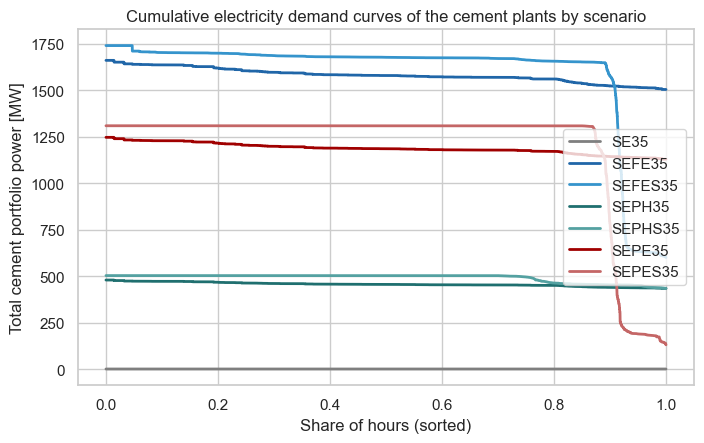

In [53]:
# --- Cell 13 (publication label): Demand duration curves (Seaborn) with storage vs non-storage colour standard ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Colour standard (fixed) ----
COLOR_SE35_GRAY       = "#7f7f7f"

COLOR_SEFE35_DARK     = "#2066a8"
COLOR_SEFES35_LIGHT   = "#3594cc"

COLOR_SEPH35_DARK     = "#1f6f6f"
COLOR_SEPHS35_LIGHT   = "#54a1a1"

COLOR_SEPE35_DARK     = "#a00000"
COLOR_SEPES35_LIGHT   = "#c46666"

scenario_palette = {
    "SE35":    COLOR_SE35_GRAY,
    "SEFE35":  COLOR_SEFE35_DARK,
    "SEFES35": COLOR_SEFES35_LIGHT,
    "SEPH35":  COLOR_SEPH35_DARK,
    "SEPHS35": COLOR_SEPHS35_LIGHT,
    "SEPE35":  COLOR_SEPE35_DARK,
    "SEPES35": COLOR_SEPES35_LIGHT,
}

# Preferred order: baseline then each family as (no storage, storage)
scenario_order = ["SE35", "SEFE35", "SEFES35", "SEPH35", "SEPHS35", "SEPE35", "SEPES35"]

# ---- Aggregate across plants: total portfolio power per timestamp and scenario_name ----
ts_total = (
    df.sort_values(["scenario_name", "timestamp"])
      .groupby(["scenario_name", "timestamp"], as_index=False)
      .agg(total_power_MW=("Total Power Input [MW_e]", "sum"))
)

# Keep only scenarios we have colours for (prevents random seaborn defaults)
ts_total = ts_total[ts_total["scenario_name"].isin(scenario_palette.keys())].copy()

# Enforce ordering for consistent legend/plot
present = ts_total["scenario_name"].unique().tolist()
ordered_present = [s for s in scenario_order if s in present]
ts_total["scenario_name"] = pd.Categorical(ts_total["scenario_name"], categories=ordered_present, ordered=True)

# ---- Build duration curve ranks within each scenario_name ----
ddc = ts_total.copy()
ddc["rank"] = ddc.groupby("scenario_name")["total_power_MW"].rank(method="first", ascending=False)
ddc["rank_frac"] = ddc["rank"] / ddc.groupby("scenario_name")["rank"].transform("max")

# Sort for clean lines
ddc = ddc.sort_values(["scenario_name", "rank_frac"])

# ---- Plot with seaborn ----
sns.set_theme(style="whitegrid", context="notebook") 

plt.figure(figsize=(7.2, 4.6))
ax = sns.lineplot(
    data=ddc,
    x="rank_frac",
    y="total_power_MW",
    hue="scenario_name",
    hue_order=ordered_present,
    palette=scenario_palette,
    linewidth=2.0,
    legend="full"
)

ax.set_xlabel("Share of hours (sorted)")
ax.set_ylabel("Total cement portfolio power [MW]")
ax.set_title("Cumulative electricity demand curves of the cement plants by scenario")

# Legend formatting (scenario_name only)
leg = ax.legend(title=None, frameon=True, loc="best")
for t in leg.get_texts():
    t.set_text(str(t.get_text()))

plt.tight_layout()
plt.show()


In [54]:
# --- Cell B: Build paper-ready tables and export (Excel + CSV) ---

from pathlib import Path
import numpy as np
import pandas as pd

# ---------- 0) Output directory ----------
OUT_DIR = Path("./results_tables")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- 1) Required columns ----------
required_cols = [
    "scenario_id","scenario_name","config","tes","plant_id","timestamp","t","dt_hours",
    "Clinker Rate [t/h]",
    "Total CO2 [tCO2/step]",
    "Total Variable Cost [€]",
    "Total Power Input [MW_e]",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in df: {missing}")

# Ensure operational NaNs are already filled (as done earlier). If not, do it here:
price_like = [c for c in df.columns if ("Price" in c) or ("Cost" in c) or ("Marginal" in c)]
meta_like = ["scenario_id","scenario_name","config","tes","plant_id","t","timestamp","dt_hours"]
operational_cols = [c for c in df.columns if c not in meta_like + price_like]
df[operational_cols] = df[operational_cols].fillna(0.0)

# ---------- 2) Plant-level annual emissions + cost accounting ----------
group_cols = ["scenario_id","scenario_name","config","tes","plant_id"]

plant_env = (
    df.groupby(group_cols, as_index=False)
    .agg(
        # rate -> total
        clinker_t=("Clinker Rate [t/h]", lambda s: float((s * df.loc[s.index, "dt_hours"]).sum())),
        # per-step totals -> sum (already per hour)
        co2_t=("Total CO2 [tCO2/step]", "sum"),
        var_cost_eur=("Total Variable Cost [€]", "sum"),
    )
)

plant_env["co2_t_per_t_clinker"] = plant_env["co2_t"] / plant_env["clinker_t"].replace(0, np.nan)
plant_env["eur_per_t_clinker"]   = plant_env["var_cost_eur"] / plant_env["clinker_t"].replace(0, np.nan)

# ---------- 3) Scenario-level totals (sum across 8 plants) ----------
scen_env = (
    plant_env.groupby(["scenario_id","scenario_name","config","tes"], as_index=False)
    .agg(
        n_plants=("plant_id","nunique"),
        clinker_t=("clinker_t","sum"),
        co2_t=("co2_t","sum"),
        var_cost_eur=("var_cost_eur","sum"),
    )
)
scen_env["co2_t_per_t_clinker"] = scen_env["co2_t"] / scen_env["clinker_t"].replace(0, np.nan)
scen_env["eur_per_t_clinker"]   = scen_env["var_cost_eur"] / scen_env["clinker_t"].replace(0, np.nan)

# ---------- 4) Scenario-level operational KPIs (portfolio) ----------
# Electricity MWh: MW_e * hours
df["Total Power Input Energy [MWh_e]"] = df["Total Power Input [MW_e]"] * df["dt_hours"]

# Thermal + TES energy columns (if present)
thermal_in_cols = [
    "Calciner NG [MW_th]","Calciner H2 [MW_th]","Calciner Coal [MW_th]",
    "Kiln NG [MW_th]","Kiln H2 [MW_th]","Kiln Coal [MW_th]"
]
tes_flow_cols = ["TES Charge [MW_th]","TES Discharge [MW_th]"]

for c in thermal_in_cols + tes_flow_cols:
    if c in df.columns:
        df[c.replace("[MW_th]","Energy [MWh_th]")] = df[c] * df["dt_hours"]

thermal_energy_cols = [c.replace("[MW_th]","Energy [MWh_th]") for c in thermal_in_cols if c in df.columns]
tes_charge_col = "TES Charge Energy [MWh_th]" if "TES Charge [MW_th]" in df.columns else None
tes_dis_col    = "TES Discharge Energy [MWh_th]" if "TES Discharge [MW_th]" in df.columns else None

scen_ops = (
    df.groupby(["scenario_id","scenario_name","config","tes"], as_index=False)
    .agg(
        avg_total_power_MW=("Total Power Input [MW_e]","mean"),
        peak_total_power_MW=("Total Power Input [MW_e]","max"),
        p95_total_power_MW=("Total Power Input [MW_e]", lambda s: float(np.quantile(s, 0.95))),
        elec_MWh=("Total Power Input Energy [MWh_e]","sum"),
    )
)

# Total thermal input (exclude TES flows)
if thermal_energy_cols:
    thermal_sum = (
        df.groupby(["scenario_id","scenario_name","config","tes"])[thermal_energy_cols]
        .sum()
        .sum(axis=1)
        .rename("thermal_MWhth")
        .reset_index()
    )
    scen_ops = scen_ops.merge(thermal_sum, on=["scenario_id","scenario_name","config","tes"], how="left")
else:
    scen_ops["thermal_MWhth"] = 0.0

# TES throughput
if tes_charge_col and tes_dis_col and tes_charge_col in df.columns and tes_dis_col in df.columns:
    tes_sum = (
        df.groupby(["scenario_id","scenario_name","config","tes"])[[tes_charge_col, tes_dis_col]]
        .sum()
        .rename(columns={tes_charge_col:"tes_charge_MWhth", tes_dis_col:"tes_discharge_MWhth"})
        .reset_index()
    )
    scen_ops = scen_ops.merge(tes_sum, on=["scenario_id","scenario_name","config","tes"], how="left")
else:
    scen_ops["tes_charge_MWhth"] = 0.0
    scen_ops["tes_discharge_MWhth"] = 0.0

for c in ["thermal_MWhth","tes_charge_MWhth","tes_discharge_MWhth"]:
    scen_ops[c] = scen_ops[c].fillna(0.0)

# ---------- 5) Merge into one paper-ready scenario table ----------
scenario_table = (
    scen_env.merge(scen_ops, on=["scenario_id","scenario_name","config","tes"], how="left")
)

# Add intensities that are useful for results discussion
scenario_table["elec_MWh_per_t_clinker"] = scenario_table["elec_MWh"] / scenario_table["clinker_t"].replace(0, np.nan)
scenario_table["thermal_MWhth_per_t_clinker"] = scenario_table["thermal_MWhth"] / scenario_table["clinker_t"].replace(0, np.nan)

# Optional: guard for BAU where elec_MWh=0 (avoid inf)
scenario_table["eur_per_MWh_e"] = scenario_table["var_cost_eur"] / scenario_table["elec_MWh"].replace(0, np.nan)

# Order columns (paper-friendly)
col_order = [
    "scenario_name","config","tes","n_plants",
    "clinker_t",
    "elec_MWh","elec_MWh_per_t_clinker",
    "thermal_MWhth","thermal_MWhth_per_t_clinker",
    "tes_charge_MWhth","tes_discharge_MWhth",
    "avg_total_power_MW","p95_total_power_MW","peak_total_power_MW",
    "co2_t","co2_t_per_t_clinker",
    "var_cost_eur","eur_per_t_clinker",
]
scenario_table = scenario_table.sort_values(["scenario_name"]).loc[:, [c for c in col_order if c in scenario_table.columns]]

# ---------- 6) Rounding for readability ----------
def round_cols(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    for c in df_out.columns:
        if pd.api.types.is_numeric_dtype(df_out[c]):
            # use different rounding based on magnitude
            if "per_t" in c or "per_MWh" in c:
                df_out[c] = df_out[c].round(4)
            elif "power" in c:
                df_out[c] = df_out[c].round(3)
            else:
                df_out[c] = df_out[c].round(3)
    return df_out

scenario_table_rounded = round_cols(scenario_table)
plant_table_rounded = round_cols(plant_env)

display(scenario_table_rounded)

# ---------- 7) Export ----------
xlsx_path = OUT_DIR / "cement_results_tables.xlsx"
csv_scen_path = OUT_DIR / "scenario_table.csv"
csv_plant_path = OUT_DIR / "plant_table.csv"

scenario_table_rounded.to_csv(csv_scen_path, index=False)
plant_table_rounded.to_csv(csv_plant_path, index=False)

# with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
#     scenario_table_rounded.to_excel(writer, sheet_name="Scenario_Summary", index=False)
#     plant_table_rounded.to_excel(writer, sheet_name="Plant_Summary", index=False)
#     scen_env.to_excel(writer, sheet_name="Scenario_Env_Raw", index=False)
#     scen_ops.to_excel(writer, sheet_name="Scenario_Ops_Raw", index=False)

# print(f"Wrote: {xlsx_path}")
# print(f"Wrote: {csv_scen_path}")
# print(f"Wrote: {csv_plant_path}")


,scenario_name,config,tes,n_plants,clinker_t,elec_MWh,elec_MWh_per_t_clinker,thermal_MWhth,thermal_MWhth_per_t_clinker,tes_charge_MWhth,tes_discharge_MWhth,avg_total_power_MW,p95_total_power_MW,peak_total_power_MW,co2_t,co2_t_per_t_clinker,var_cost_eur,eur_per_t_clinker
0,SE35,BAU,False,8,11974602.48,0.000000e+00,0.0000,1.182692e+07,0.9877,0.000,0.000,0.000,0.000,0.000,1.045137e+07,0.8728,1.770040e+09,147.8162
1,SEFE35,FE,False,8,11974602.48,1.385421e+07,1.1570,0.000000e+00,0.0000,0.000,0.000,197.691,305.948,320.861,6.418387e+06,0.5360,1.979087e+09,165.2737
4,SEFES35,FE,True,8,11974602.48,1.396204e+07,1.1660,0.000000e+00,0.0000,718926.408,642957.201,199.230,324.554,336.000,6.418387e+06,0.5360,1.902428e+09,158.8719
3,SEPE35,PE,False,8,11974602.48,1.039900e+07,0.8684,3.326545e+06,0.2778,0.000,0.000,148.388,229.645,240.839,7.528789e+06,0.6287,1.991659e+09,166.3236
6,SEPES35,PE,True,8,11974602.48,1.048485e+07,0.8756,3.326545e+06,0.2778,881061.002,799500.590,149.613,252.880,252.880,7.528789e+06,0.6287,1.900469e+09,158.7083
2,SEPH35,PH,False,8,11974602.48,3.993451e+06,0.3335,1.430326e+07,1.1945,0.000,0.000,56.984,88.189,92.488,8.940837e+06,0.7466,2.101371e+09,175.4857
5,SEPHS35,PH,True,8,11974602.48,4.300477e+06,0.3591,1.398598e+07,1.1680,295927.629,285559.652,61.365,97.110,97.110,8.867924e+06,0.7406,2.094350e+09,174.8994


In [55]:
# --- Cell P1: Common plot settings + scenario order ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scenario_order = ["SE35", "SEFE35", "SEPH35", "SEPE35", "SEFES35", "SEPHS35", "SEPES35"]

def order_by_scenario(df_in, col="scenario_name"):
    df_out = df_in.copy()
    if col in df_out.columns:
        df_out[col] = pd.Categorical(df_out[col], categories=scenario_order, ordered=True)
        df_out = df_out.sort_values(col)
    return df_out


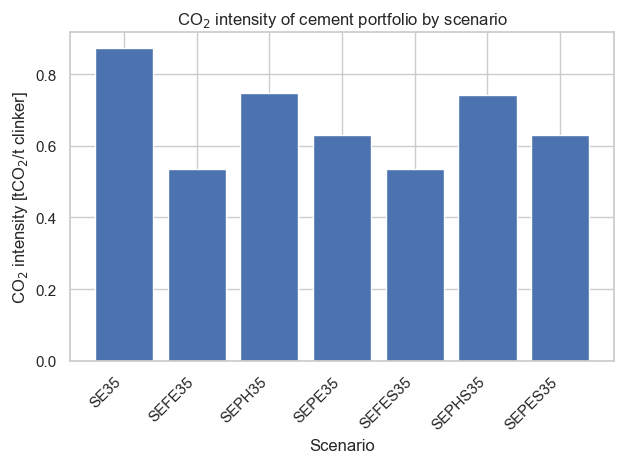

In [21]:
# --- Cell P2: CO2 intensity by scenario (tCO2/t clinker) ---

# Assumes scen_env exists (from your Cell A corrected) OR scenario_table exists (from export cell)
if "scen_env" in globals():
    plot_df = scen_env[["scenario_name", "co2_t_per_t_clinker"]].copy()
elif "scenario_table" in globals():
    plot_df = scenario_table[["scenario_name", "co2_t_per_t_clinker"]].copy()
else:
    raise NameError("Expected 'scen_env' or 'scenario_table' in memory.")

plot_df = order_by_scenario(plot_df)

plt.figure()
plt.bar(plot_df["scenario_name"].astype(str), plot_df["co2_t_per_t_clinker"])
plt.ylabel("CO$_2$ intensity [tCO$_2$/t clinker]")
plt.xlabel("Scenario")
plt.title("CO$_2$ intensity of cement portfolio by scenario")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


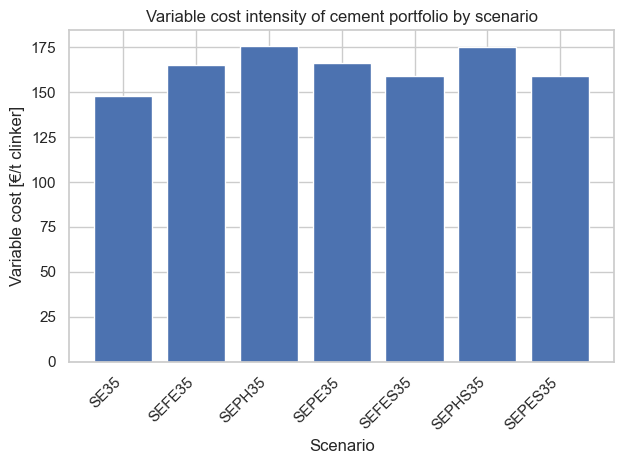

In [22]:
# --- Cell P3: Variable cost per tonne clinker (€/t clinker) ---

if "scen_env" in globals():
    plot_df = scen_env[["scenario_name", "eur_per_t_clinker"]].copy()
elif "scenario_table" in globals():
    plot_df = scenario_table[["scenario_name", "eur_per_t_clinker"]].copy()
else:
    raise NameError("Expected 'scen_env' or 'scenario_table' in memory.")

plot_df = order_by_scenario(plot_df)

plt.figure()
plt.bar(plot_df["scenario_name"].astype(str), plot_df["eur_per_t_clinker"])
plt.ylabel("Variable cost [€/t clinker]")
plt.xlabel("Scenario")
plt.title("Variable cost intensity of cement portfolio by scenario")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Component sum vs Total Power Input energy (TWh). Gaps should be ~0 (numerical noise only):


,scenario_name,Total_Elec_TWh,components_sum_TWh,check_gap_TWh
0,SE35,0.000000,0.000000,0.000000e+00
1,SEFE35,13.854207,13.854207,0.000000e+00
2,SEFES35,13.962039,13.934175,2.786465e-02
5,SEPH35,3.993451,3.993451,0.000000e+00
6,SEPHS35,4.300477,4.300477,8.881784e-16
3,SEPE35,10.398997,10.398997,0.000000e+00
4,SEPES35,10.484850,10.484850,0.000000e+00


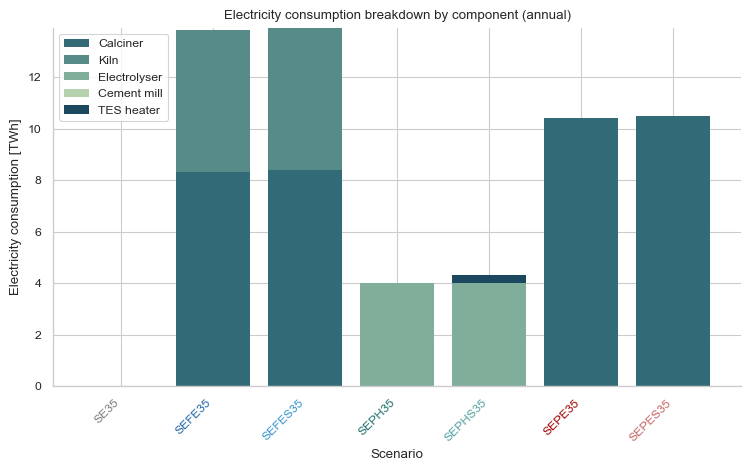

In [56]:
# --- Cell P4 (STACKED, seaborn-styled): Electricity consumption breakdown by component (TWh) + sanity check ---
# Paper-friendly "Sequential (teal)" palette from your reference image (lighter, less contrast)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

# ---- Scenario colour standard (for scenario ordering + tick cues) ----
COLOR_SE35_GRAY       = "#7f7f7f"
COLOR_SEFE35_DARK     = "#2066a8"
COLOR_SEFES35_LIGHT   = "#3594cc"
COLOR_SEPH35_DARK     = "#1f6f6f"
COLOR_SEPHS35_LIGHT   = "#54a1a1"
COLOR_SEPE35_DARK     = "#a00000"
COLOR_SEPES35_LIGHT   = "#c46666"

scenario_palette = {
    "SE35":    COLOR_SE35_GRAY,
    "SEFE35":  COLOR_SEFE35_DARK,
    "SEFES35": COLOR_SEFES35_LIGHT,
    "SEPH35":  COLOR_SEPH35_DARK,
    "SEPHS35": COLOR_SEPHS35_LIGHT,
    "SEPE35":  COLOR_SEPE35_DARK,
    "SEPES35": COLOR_SEPES35_LIGHT,
}
scenario_order = ["SE35", "SEFE35", "SEFES35", "SEPH35", "SEPHS35", "SEPE35", "SEPES35"]

# ---- Components ----
component_cols = {
    "Calciner Power [MW_e]": "Calciner",
    "Kiln Power [MW_e]": "Kiln",
    "Electrolyser Power [MW_e]": "Electrolyser",
    "Cement Mill Power [MW_e]": "Cement mill",
    "TES Heater Power [MW_e]": "TES heater",
}

# ---- Component colours: Sequential (teal) from your reference image (Teal1..Teal5) ----
# Teal1 #b5d1ae, Teal2 #80ae9a, Teal3 #568b87, Teal4 #326b77, Teal5 #1b485e, Teal6 #122740
# Use Teal1..Teal5 only (avoid Teal6: too dark).
component_color_map = {
    "Calciner":     "#326b77",  # Teal4 (mid-dark, but not heavy)
    "Kiln":         "#568b87",  # Teal3
    "Electrolyser": "#80ae9a",  # Teal2
    "Cement mill":  "#b5d1ae",  # Teal1 (lightest)
    "TES heater":   "#1b485e",  # Teal5 (darkest among used, still paper-ok)
}

tmp = df.copy()
tmp["dt_hours"] = tmp["dt_hours"].fillna(1.0)

for c in component_cols:
    if c not in tmp.columns:
        tmp[c] = 0.0

for c in component_cols:
    tmp[c + "_MWh"] = tmp[c] * tmp["dt_hours"]

tmp["Total_Elec_MWh"] = tmp["Total Power Input [MW_e]"] * tmp["dt_hours"]

sum_cols = [c + "_MWh" for c in component_cols] + ["Total_Elec_MWh"]
comp_df = tmp.groupby("scenario_name", as_index=False)[sum_cols].sum()

for c in [c + "_MWh" for c in component_cols]:
    comp_df[c.replace("_MWh", "_TWh")] = comp_df[c] / 1e6
comp_df["Total_Elec_TWh"] = comp_df["Total_Elec_MWh"] / 1e6

comp_df = comp_df[comp_df["scenario_name"].isin(scenario_palette.keys())].copy()
present = comp_df["scenario_name"].unique().tolist()
ordered_present = [s for s in scenario_order if s in present]
comp_df["scenario_name"] = pd.Categorical(comp_df["scenario_name"], categories=ordered_present, ordered=True)
comp_df = comp_df.sort_values("scenario_name")

component_twh_cols = [c + "_TWh" for c in component_cols]
comp_df["components_sum_TWh"] = comp_df[component_twh_cols].sum(axis=1)
comp_df["check_gap_TWh"] = comp_df["Total_Elec_TWh"] - comp_df["components_sum_TWh"]

print("Component sum vs Total Power Input energy (TWh). Gaps should be ~0 (numerical noise only):")
display(comp_df[["scenario_name", "Total_Elec_TWh", "components_sum_TWh", "check_gap_TWh"]])

# ---- Plot (stacked) ----
x = comp_df["scenario_name"].astype(str).tolist()
xpos = np.arange(len(x))
bottom = np.zeros(len(comp_df))

plt.figure(figsize=(7.6, 4.8))
ax = plt.gca()

for col, label in component_cols.items():
    y = comp_df[col + "_TWh"].values
    ax.bar(
        xpos,
        y,
        bottom=bottom,
        label=label,
        color=component_color_map[label],
        linewidth=0
    )
    bottom += y

ax.set_ylabel("Electricity consumption [TWh]")
ax.set_xlabel("Scenario")
ax.set_title("Electricity consumption breakdown by component (annual)")

ax.set_xticks(xpos)
ax.set_xticklabels(x, rotation=45, ha="right")

# Scenario tick colours (your dark/light standard)
for tick in ax.get_xticklabels():
    scen = tick.get_text()
    if scen in scenario_palette:
        tick.set_color(scenario_palette[scen])

ax.legend(title=None, frameon=True, loc="best")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


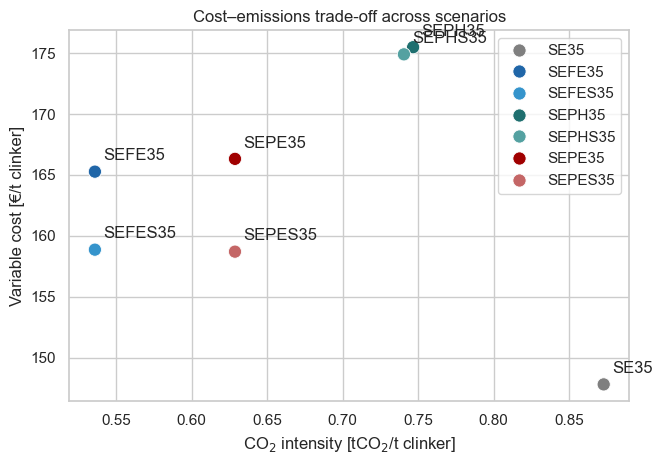

In [57]:
# --- Cell P5: Cost–emissions trade-off (Seaborn annotated scatter) with storage vs non-storage colour standard ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Colour standard (fixed) ----
COLOR_SE35_GRAY       = "#7f7f7f"

COLOR_SEFE35_DARK     = "#2066a8"
COLOR_SEFES35_LIGHT   = "#3594cc"

COLOR_SEPH35_DARK     = "#1f6f6f"
COLOR_SEPHS35_LIGHT   = "#54a1a1"

COLOR_SEPE35_DARK     = "#a00000"
COLOR_SEPES35_LIGHT   = "#c46666"

scenario_palette = {
    "SE35":    COLOR_SE35_GRAY,
    "SEFE35":  COLOR_SEFE35_DARK,
    "SEFES35": COLOR_SEFES35_LIGHT,
    "SEPH35":  COLOR_SEPH35_DARK,
    "SEPHS35": COLOR_SEPHS35_LIGHT,
    "SEPE35":  COLOR_SEPE35_DARK,
    "SEPES35": COLOR_SEPES35_LIGHT,
}
scenario_order = ["SE35", "SEFE35", "SEFES35", "SEPH35", "SEPHS35", "SEPE35", "SEPES35"]

# ---- Load scenario table ----
if "scen_env" in globals():
    s = scen_env[["scenario_name", "co2_t_per_t_clinker", "eur_per_t_clinker"]].copy()
elif "scenario_table" in globals():
    s = scenario_table[["scenario_name", "co2_t_per_t_clinker", "eur_per_t_clinker"]].copy()
else:
    raise NameError("Expected 'scen_env' or 'scenario_table' in memory.")

# Keep only scenarios we have colours for
s = s[s["scenario_name"].isin(scenario_palette.keys())].copy()

# Order consistently (use your helper if available; otherwise categorical order)
if "order_by_scenario" in globals():
    s = order_by_scenario(s)
else:
    present = s["scenario_name"].unique().tolist()
    ordered_present = [x for x in scenario_order if x in present]
    s["scenario_name"] = pd.Categorical(s["scenario_name"], categories=ordered_present, ordered=True)
    s = s.sort_values("scenario_name")

# Final ordered list for hue
ordered_present = [x for x in scenario_order if x in s["scenario_name"].astype(str).unique().tolist()]

# ---- Plot (seaborn) ----
sns.set_theme(style="whitegrid", context="notebook")   # bigger than "paper"


plt.figure(figsize=(6.8, 4.8))
ax = sns.scatterplot(
    data=s,
    x="co2_t_per_t_clinker",
    y="eur_per_t_clinker",
    hue="scenario_name",
    hue_order=ordered_present,
    palette=scenario_palette,
    s=90,
    edgecolor="white",
    linewidth=0.6,
    legend="full"
)

# Annotate each point with scenario_name (keeps visual pairing side-by-side via colour)
for _, r in s.iterrows():
    ax.annotate(
        str(r["scenario_name"]),
        (float(r["co2_t_per_t_clinker"]), float(r["eur_per_t_clinker"])),
        textcoords="offset points",
        xytext=(6, 6),
        ha="left",
        va="bottom"
    )

ax.set_xlabel("CO$_2$ intensity [tCO$_2$/t clinker]")
ax.set_ylabel("Variable cost [€/t clinker]")
ax.set_title("Cost–emissions trade-off across scenarios")

# Legend formatting (scenario_name only)
leg = ax.legend(title=None, frameon=True, loc="best")
plt.tight_layout()
plt.show()


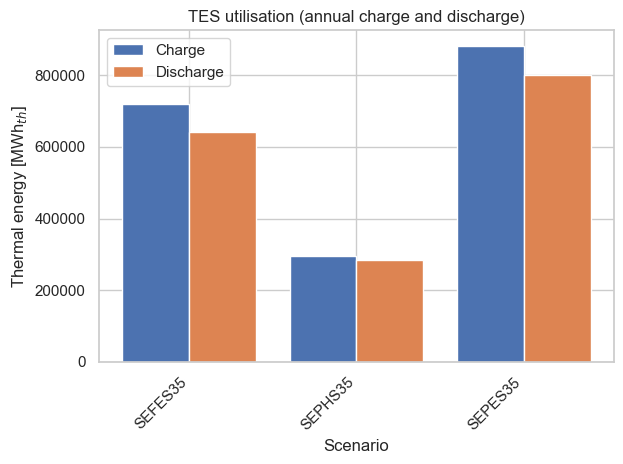

In [26]:
# --- Cell P6: TES utilisation (charge/discharge) by scenario_name ---

# Use your scenario_table if available; otherwise rebuild quickly from df
if "scenario_table" in globals() and "tes_charge_MWhth" in scenario_table.columns:
    tes_df = scenario_table[["scenario_name", "tes_charge_MWhth", "tes_discharge_MWhth"]].copy()
else:
    # derive from df (robust)
    tmp = df.copy()
    tmp["dt_hours"] = tmp["dt_hours"].fillna(1.0)
    for c in ["TES Charge [MW_th]", "TES Discharge [MW_th]"]:
        if c not in tmp.columns:
            tmp[c] = 0.0
        tmp[c + "_MWhth"] = tmp[c] * tmp["dt_hours"]
    tes_df = (
        tmp.groupby("scenario_name", as_index=False)[["TES Charge [MW_th]_MWhth", "TES Discharge [MW_th]_MWhth"]]
        .sum()
        .rename(columns={
            "TES Charge [MW_th]_MWhth": "tes_charge_MWhth",
            "TES Discharge [MW_th]_MWhth": "tes_discharge_MWhth",
        })
    )

tes_df = order_by_scenario(tes_df)
tes_df = tes_df[(tes_df["tes_charge_MWhth"] > 0) | (tes_df["tes_discharge_MWhth"] > 0)]

x = tes_df["scenario_name"].astype(str).tolist()
x_idx = np.arange(len(x))
w = 0.4

plt.figure()
plt.bar(x_idx - w/2, tes_df["tes_charge_MWhth"].values, width=w, label="Charge")
plt.bar(x_idx + w/2, tes_df["tes_discharge_MWhth"].values, width=w, label="Discharge")
plt.xticks(x_idx, x, rotation=45, ha="right")
plt.ylabel("Thermal energy [MWh$_{th}$]")
plt.xlabel("Scenario")
plt.title("TES utilisation (annual charge and discharge)")
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
# --- Cell B1 (improved): Abatement table vs BAU (scenario_name baseline) ---

import numpy as np
import pandas as pd

# Choose BAU baseline by scenario_name (paper label)
BAU_SCEN = "SE35"   # BAU in your loaded set
bau = scen_env.loc[scen_env["scenario_name"] == BAU_SCEN]
if bau.empty:
    raise ValueError(f"Baseline scenario '{BAU_SCEN}' not found in scen_env.")
if len(bau) > 1:
    raise ValueError(f"Baseline scenario '{BAU_SCEN}' is not unique. Check scen_env.")
bau = bau.iloc[0]

bau_co2 = float(bau["co2_t"])
bau_cost = float(bau["var_cost_eur"])
bau_clinker = float(bau["clinker_t"])

cmp = scen_env.copy()

# baseline columns
cmp["bau_co2_t"] = bau_co2
cmp["bau_cost_eur"] = bau_cost
cmp["bau_clinker_t"] = bau_clinker

# deltas and abatement (positive = abatement)
cmp["co2_abated_t"] = cmp["bau_co2_t"] - cmp["co2_t"]
cmp["delta_cost_eur"] = cmp["var_cost_eur"] - cmp["bau_cost_eur"]

# Abatement cost only defined when abatement > 0 (avoid divide by ~0)
eps = 1e-6
cmp["abatement_cost_eur_per_tco2"] = np.where(
    cmp["co2_abated_t"] > eps,
    cmp["delta_cost_eur"] / cmp["co2_abated_t"],
    np.nan
)

# convenience units
cmp["co2_abated_kt"] = cmp["co2_abated_t"] / 1e3
cmp["delta_cost_Meur"] = cmp["delta_cost_eur"] / 1e6

# Extra interpretability: intensity deltas vs BAU
cmp["delta_co2_intensity"] = cmp["co2_t_per_t_clinker"] - float(bau["co2_t_per_t_clinker"])
cmp["delta_cost_intensity"] = cmp["eur_per_t_clinker"] - float(bau["eur_per_t_clinker"])

# Order and select columns (scenario_name first)
abatement_table = (
    cmp[[
        "scenario_name","config","tes",
        "clinker_t",
        "co2_t","co2_abated_kt","co2_t_per_t_clinker","delta_co2_intensity",
        "var_cost_eur","delta_cost_Meur","eur_per_t_clinker","delta_cost_intensity",
        "abatement_cost_eur_per_tco2",
    ]]
    .sort_values("scenario_name")
    .reset_index(drop=True)
)

pd.set_option("display.max_rows", 50)
display(abatement_table)


,scenario_name,config,tes,clinker_t,co2_t,co2_abated_kt,co2_t_per_t_clinker,delta_co2_intensity,var_cost_eur,delta_cost_Meur,eur_per_t_clinker,delta_cost_intensity,abatement_cost_eur_per_tco2
0,SE35,BAU,False,11974602.48,1.045137e+07,0.000000,0.872794,0.000000,1.770040e+09,0.000000,147.816160,0.000000,NaN
1,SEFE35,FE,False,11974602.48,6.418387e+06,4032.978259,0.536000,-0.336794,1.979087e+09,209.047438,165.273728,17.457568,51.834506
2,SEFES35,FE,True,11974602.48,6.418387e+06,4032.978259,0.536000,-0.336794,1.902428e+09,132.387849,158.871880,11.055720,32.826323
3,SEPE35,PE,False,11974602.48,7.528789e+06,2922.575766,0.628730,-0.244065,1.991659e+09,221.619348,166.323609,18.507449,75.830146
4,SEPES35,PE,True,11974602.48,7.528789e+06,2922.575766,0.628730,-0.244065,1.900469e+09,130.429184,158.708311,10.892151,44.628162
5,SEPH35,PH,False,11974602.48,8.940837e+06,1510.528247,0.746650,-0.126144,2.101371e+09,331.331370,175.485669,27.669509,219.348014
6,SEPHS35,PH,True,11974602.48,8.867924e+06,1583.441145,0.740561,-0.132233,2.094350e+09,324.310586,174.899363,27.083203,204.813793


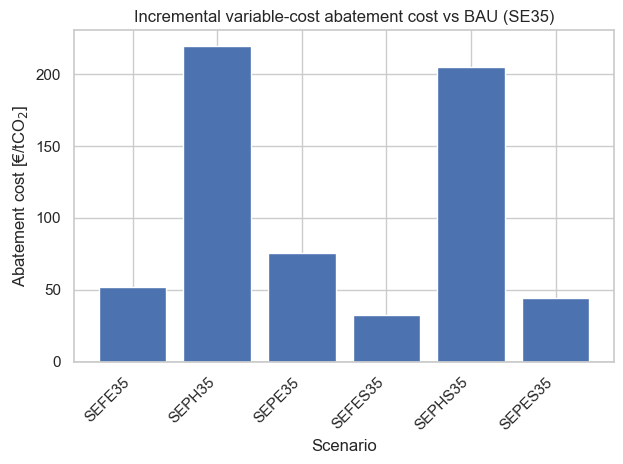

In [28]:
# --- Cell B2: Abatement cost bar chart (€/tCO2) by scenario_name ---

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Requires abatement_table from Cell B1
if "abatement_table" not in globals():
    raise NameError("Run Cell B1 first to create 'abatement_table'.")

plot_df = abatement_table.copy()

# Remove BAU itself (abatement = 0) and cases with no abatement (NaN abatement cost)
plot_df = plot_df[plot_df["scenario_name"] != "SE35"].copy()
plot_df = plot_df.dropna(subset=["abatement_cost_eur_per_tco2"]).copy()

# Order by scenario order (optional)
scenario_order = ["SE35", "SEFE35", "SEPH35", "SEPE35", "SEFES35", "SEPHS35", "SEPES35"]
plot_df["scenario_name"] = pd.Categorical(plot_df["scenario_name"], categories=scenario_order, ordered=True)
plot_df = plot_df.sort_values("scenario_name")

plt.figure()
plt.bar(plot_df["scenario_name"].astype(str), plot_df["abatement_cost_eur_per_tco2"])
plt.axhline(0, linewidth=1)

plt.ylabel("Abatement cost [€/tCO$_2$]")
plt.xlabel("Scenario")
plt.title("Incremental variable-cost abatement cost vs BAU (SE35)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


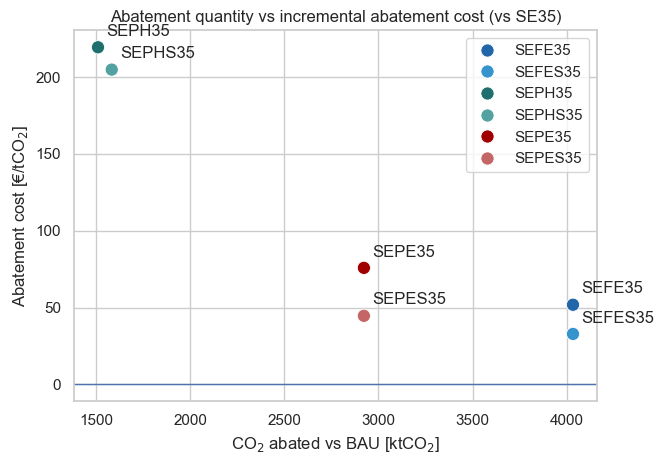

In [59]:
# --- Cell B3: Abatement quantity vs abatement cost (Seaborn annotated scatter) ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Colour standard (fixed) ----
COLOR_SE35_GRAY       = "#7f7f7f"

COLOR_SEFE35_DARK     = "#2066a8"
COLOR_SEFES35_LIGHT   = "#3594cc"

COLOR_SEPH35_DARK     = "#1f6f6f"
COLOR_SEPHS35_LIGHT   = "#54a1a1"

COLOR_SEPE35_DARK     = "#a00000"
COLOR_SEPES35_LIGHT   = "#c46666"

scenario_palette = {
    "SE35":    COLOR_SE35_GRAY,
    "SEFE35":  COLOR_SEFE35_DARK,
    "SEFES35": COLOR_SEFES35_LIGHT,
    "SEPH35":  COLOR_SEPH35_DARK,
    "SEPHS35": COLOR_SEPHS35_LIGHT,
    "SEPE35":  COLOR_SEPE35_DARK,
    "SEPES35": COLOR_SEPES35_LIGHT,
}
scenario_order = ["SE35", "SEFE35", "SEFES35", "SEPH35", "SEPHS35", "SEPE35", "SEPES35"]

# ---- Prepare data ----
plot_df = abatement_table.copy()
plot_df = plot_df[plot_df["scenario_name"].isin(scenario_palette.keys())].copy()
plot_df = plot_df[plot_df["scenario_name"] != "SE35"].copy()  # vs BAU
plot_df = plot_df.dropna(subset=["abatement_cost_eur_per_tco2", "co2_abated_kt"]).copy()

# Enforce order for legend
present = plot_df["scenario_name"].unique().tolist()
ordered_present = [s for s in scenario_order if s in present]
plot_df["scenario_name"] = pd.Categorical(plot_df["scenario_name"], categories=ordered_present, ordered=True)
plot_df = plot_df.sort_values("scenario_name")

# ---- Plot (seaborn) ----
sns.set_theme(style="whitegrid", context="notebook")   # bigger than "paper"


plt.figure(figsize=(6.8, 4.8))
ax = sns.scatterplot(
    data=plot_df,
    x="co2_abated_kt",
    y="abatement_cost_eur_per_tco2",
    hue="scenario_name",
    hue_order=ordered_present,
    palette=scenario_palette,
    s=90,
    edgecolor="white",
    linewidth=0.6,
    legend="full"
)

# Annotations
for _, r in plot_df.iterrows():
    ax.annotate(
        str(r["scenario_name"]),
        (float(r["co2_abated_kt"]), float(r["abatement_cost_eur_per_tco2"])),
        textcoords="offset points",
        xytext=(6, 6),
        ha="left",
        va="bottom"
    )

# Zero line
ax.axhline(0, linewidth=1)

ax.set_xlabel("CO$_2$ abated vs BAU [ktCO$_2$]")
ax.set_ylabel("Abatement cost [€/tCO$_2$]")
ax.set_title("Abatement quantity vs incremental abatement cost (vs SE35)")

# Legend formatting (scenario_name only)
leg = ax.legend(title=None, frameon=True, loc="best")

plt.tight_layout()
plt.show()


In [33]:
# --- Cell B4: TES incremental effect (TES vs no-TES) within config (scenario_name-based) ---

import pandas as pd
import numpy as np

# scen_env must exist from earlier
if "scen_env" not in globals():
    raise NameError("Expected scen_env to exist. Run the scenario aggregation cell first.")

# Define pairs using scenario_name (paper label)
pair_map = {
    "FE": ("SEFE35",  "SEFES35"),
    "PH": ("SEPH35",  "SEPHS35"),
    "PE": ("SEPE35",  "SEPES35"),
}

rows = []
for cfg, (s_no, s_tes) in pair_map.items():
    a = scen_env.loc[scen_env["scenario_name"] == s_no]
    b = scen_env.loc[scen_env["scenario_name"] == s_tes]

    if a.empty or b.empty:
        raise ValueError(f"Missing scenario(s) for config={cfg}: noTES={s_no} found={not a.empty}, TES={s_tes} found={not b.empty}")
    if len(a) > 1 or len(b) > 1:
        raise ValueError(f"Scenario_name not unique for config={cfg}: {s_no} or {s_tes}")

    a = a.iloc[0]
    b = b.iloc[0]

    rows.append({
        "config": cfg,
        "scenario_noTES": s_no,
        "scenario_TES": s_tes,

        # Total impacts
        "Δ cost (TES - noTES) [M€]": (float(b["var_cost_eur"]) - float(a["var_cost_eur"])) / 1e6,
        "Δ CO2 (TES - noTES) [t]": float(b["co2_t"]) - float(a["co2_t"]),

        # Intensities (more comparable)
        "Δ cost intensity (TES - noTES) [€/t clinker]": float(b["eur_per_t_clinker"]) - float(a["eur_per_t_clinker"]),
        "Δ CO2 intensity (TES - noTES) [tCO2/t clinker]": float(b["co2_t_per_t_clinker"]) - float(a["co2_t_per_t_clinker"]),
    })

tes_effect = pd.DataFrame(rows)
display(tes_effect)


,config,scenario_noTES,scenario_TES,Δ cost (TES - noTES) [M€],Δ CO2 (TES - noTES) [t],Δ cost intensity (TES - noTES) [€/t clinker],Δ CO2 intensity (TES - noTES) [tCO2/t clinker]
0,FE,SEFE35,SEFES35,-76.659589,9.313226e-10,-6.401848,1.110223e-16
1,PH,SEPH35,SEPHS35,-7.020784,-7.291290e+04,-0.586306,-6.088962e-03
2,PE,SEPE35,SEPES35,-91.190164,0.000000e+00,-7.615298,0.000000e+00


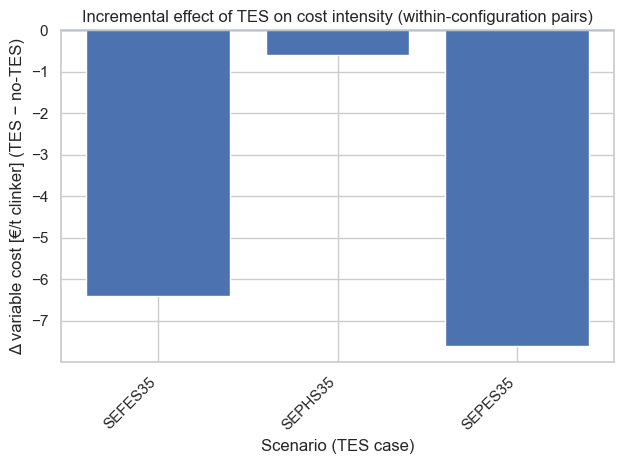

In [34]:
# --- Cell B5a (revised): TES incremental cost effect, x-ticks = TES scenario_name ---

import matplotlib.pyplot as plt
import numpy as np

# Ensure we have tes_effect from Cell B4
if "tes_effect" not in globals():
    raise NameError("Run Cell B4 first to create 'tes_effect'.")

# Use the TES scenario as the label (paper-facing)
x = tes_effect["scenario_TES"].astype(str).tolist()
y = tes_effect["Δ cost intensity (TES - noTES) [€/t clinker]"].values

plt.figure()
plt.bar(x, y)
plt.axhline(0, linewidth=1)
plt.ylabel("Δ variable cost [€/t clinker] (TES − no-TES)")
plt.xlabel("Scenario (TES case)")
plt.title("Incremental effect of TES on cost intensity (within-configuration pairs)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


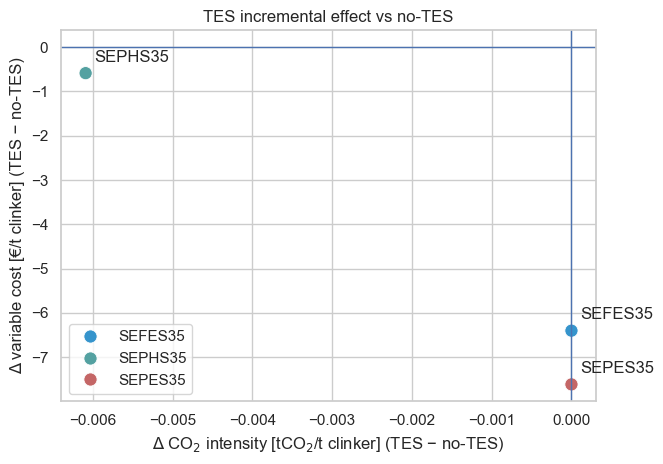

In [60]:
# --- Cell B5b (revised): TES incremental trade-off scatter (Seaborn), labels = TES scenario_name ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Colour standard (fixed) ----
COLOR_SE35_GRAY       = "#7f7f7f"

COLOR_SEFE35_DARK     = "#2066a8"
COLOR_SEFES35_LIGHT   = "#3594cc"

COLOR_SEPH35_DARK     = "#1f6f6f"
COLOR_SEPHS35_LIGHT   = "#54a1a1"

COLOR_SEPE35_DARK     = "#a00000"
COLOR_SEPES35_LIGHT   = "#c46666"

scenario_palette = {
    "SE35":    COLOR_SE35_GRAY,
    "SEFE35":  COLOR_SEFE35_DARK,
    "SEFES35": COLOR_SEFES35_LIGHT,
    "SEPH35":  COLOR_SEPH35_DARK,
    "SEPHS35": COLOR_SEPHS35_LIGHT,
    "SEPE35":  COLOR_SEPE35_DARK,
    "SEPES35": COLOR_SEPES35_LIGHT,
}
scenario_order = ["SE35", "SEFE35", "SEFES35", "SEPH35", "SEPHS35", "SEPE35", "SEPES35"]

# ---- Prepare data ----
plot_df = tes_effect.copy()

xcol = "Δ CO2 intensity (TES - noTES) [tCO2/t clinker]"
ycol = "Δ cost intensity (TES - noTES) [€/t clinker]"
label_col = "scenario_TES"

plot_df = plot_df.dropna(subset=[xcol, ycol, label_col]).copy()
plot_df[label_col] = plot_df[label_col].astype(str)

# If scenario names are exactly the TES scenarios (e.g., "SEPES35", "SEPHS35", "SEFES35"),
# we can colour them directly using the global palette.
plot_df = plot_df[plot_df[label_col].isin(scenario_palette.keys())].copy()

present = plot_df[label_col].unique().tolist()
ordered_present = [s for s in scenario_order if s in present]
plot_df[label_col] = pd.Categorical(plot_df[label_col], categories=ordered_present, ordered=True)
plot_df = plot_df.sort_values(label_col)

# ---- Plot (seaborn) ----
sns.set_theme(style="whitegrid", context="notebook")   # bigger than "paper"


plt.figure(figsize=(6.8, 4.8))
ax = sns.scatterplot(
    data=plot_df,
    x=xcol,
    y=ycol,
    hue=label_col,
    hue_order=ordered_present,
    palette=scenario_palette,
    s=90,
    edgecolor="white",
    linewidth=0.6,
    legend="full"
)

# Labels (explicit scenario text at each point)
for _, r in plot_df.iterrows():
    ax.annotate(
        str(r[label_col]),
        (float(r[xcol]), float(r[ycol])),
        textcoords="offset points",
        xytext=(6, 6),
        ha="left",
        va="bottom"
    )

# Reference lines
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel("Δ CO$_2$ intensity [tCO$_2$/t clinker] (TES − no-TES)")
ax.set_ylabel("Δ variable cost [€/t clinker] (TES − no-TES)")
ax.set_title("TES incremental effect vs no-TES")

# Legend formatting
ax.legend(title=None, frameon=True, loc="best")

plt.tight_layout()
plt.show()


In [45]:
# --- Cell C1 (corrected): Annual CO2 decomposition (scenario-level) ---

import numpy as np
import pandas as pd

co2_cols = [
    "Preheater CO2 [tCO2/step]",
    "Calciner CO2 process [tCO2/step]",
    "Calciner CO2 energy [tCO2/step]",
    "Kiln CO2 [tCO2/step]",
    "Total CO2 [tCO2/step]",
]

missing = [c for c in co2_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing CO2 columns for decomposition: {missing}")

# Ensure dt_hours exists (needed for clinker conversion)
if "dt_hours" not in df.columns:
    raise KeyError("Missing 'dt_hours'. Run the timestamp continuity / dt_hours construction cell first.")

# Scenario order (optional)
scenario_order = ["SE35", "SEFE35", "SEPH35", "SEPE35", "SEFES35", "SEPHS35", "SEPES35"]

# NOTE:
# - Clinker Rate [t/h] is a rate -> multiply by dt_hours to get tonnes.
# - CO2 columns are already tCO2/step -> sum directly (do NOT multiply by dt_hours).
co2_scen = (
    df.groupby(["scenario_name"], as_index=False)
    .agg(
        clinker_t=("Clinker Rate [t/h]", lambda s: float((s * df.loc[s.index, "dt_hours"]).sum())),
        preheater_co2_t=("Preheater CO2 [tCO2/step]", "sum"),
        calciner_process_co2_t=("Calciner CO2 process [tCO2/step]", "sum"),
        calciner_energy_co2_t=("Calciner CO2 energy [tCO2/step]", "sum"),
        kiln_co2_t=("Kiln CO2 [tCO2/step]", "sum"),
        total_co2_t=("Total CO2 [tCO2/step]", "sum"),
    )
)

# Buckets
co2_scen["process_co2_t"] = co2_scen["calciner_process_co2_t"]
co2_scen["energy_co2_t"] = co2_scen["total_co2_t"] - co2_scen["process_co2_t"]

# Shares
co2_scen["process_share"] = co2_scen["process_co2_t"] / co2_scen["total_co2_t"].replace(0, np.nan)
co2_scen["energy_share"] = co2_scen["energy_co2_t"] / co2_scen["total_co2_t"].replace(0, np.nan)

# Intensities
co2_scen["total_co2_t_per_t_clinker"]   = co2_scen["total_co2_t"] / co2_scen["clinker_t"].replace(0, np.nan)
co2_scen["process_co2_t_per_t_clinker"] = co2_scen["process_co2_t"] / co2_scen["clinker_t"].replace(0, np.nan)
co2_scen["energy_co2_t_per_t_clinker"]  = co2_scen["energy_co2_t"] / co2_scen["clinker_t"].replace(0, np.nan)

# Order rows by scenario_name
co2_scen["scenario_name"] = pd.Categorical(co2_scen["scenario_name"], categories=scenario_order, ordered=True)
co2_scen = co2_scen.sort_values("scenario_name").reset_index(drop=True)

display(co2_scen[[
    "scenario_name",
    "total_co2_t","process_co2_t","energy_co2_t",
    "process_share","energy_share",
    "total_co2_t_per_t_clinker","process_co2_t_per_t_clinker","energy_co2_t_per_t_clinker"
]])


,scenario_name,total_co2_t,process_co2_t,energy_co2_t,process_share,energy_share,total_co2_t_per_t_clinker,process_co2_t_per_t_clinker,energy_co2_t_per_t_clinker
0,SE35,1.045137e+07,6.418387e+06,4.032978e+06,0.614119,0.385881,0.872794,0.536,0.336794
1,SEFE35,6.418387e+06,6.418387e+06,0.000000e+00,1.000000,0.000000,0.536000,0.536,0.000000
2,SEPH35,8.940837e+06,6.418387e+06,2.522450e+06,0.717873,0.282127,0.746650,0.536,0.210650
3,SEPE35,7.528789e+06,6.394438e+06,1.134352e+06,0.849331,0.150669,0.628730,0.534,0.094730
4,SEFES35,6.418387e+06,6.418387e+06,0.000000e+00,1.000000,0.000000,0.536000,0.536,0.000000
5,SEPHS35,8.867924e+06,6.418387e+06,2.449537e+06,0.723776,0.276224,0.740561,0.536,0.204561
6,SEPES35,7.528789e+06,6.394438e+06,1.134352e+06,0.849331,0.150669,0.628730,0.534,0.094730


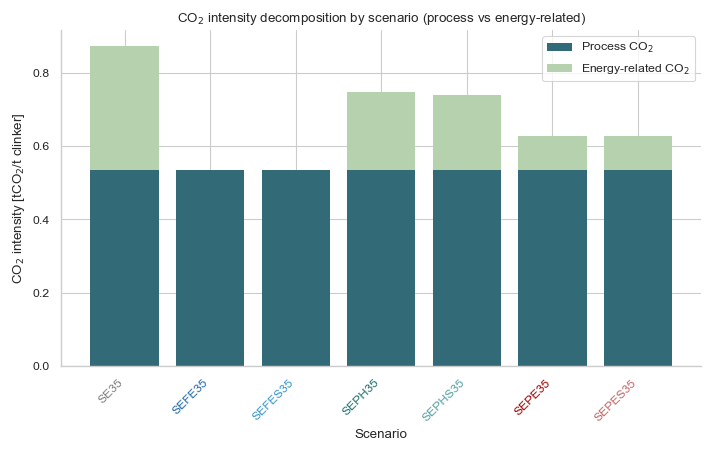

In [47]:
# --- Cell C2: Stacked bar of CO2 intensity decomposition (tCO2/t clinker) (seaborn-styled, paper-friendly) ---

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

if "co2_scen" not in globals():
    raise NameError("Run Cell C1 first to create 'co2_scen'.")

# ---- Scenario colour standard (for ordering + tick cues) ----
COLOR_SE35_GRAY       = "#7f7f7f"
COLOR_SEFE35_DARK     = "#2066a8"
COLOR_SEFES35_LIGHT   = "#3594cc"
COLOR_SEPH35_DARK     = "#1f6f6f"
COLOR_SEPHS35_LIGHT   = "#54a1a1"
COLOR_SEPE35_DARK     = "#a00000"
COLOR_SEPES35_LIGHT   = "#c46666"

scenario_palette = {
    "SE35":    COLOR_SE35_GRAY,
    "SEFE35":  COLOR_SEFE35_DARK,
    "SEFES35": COLOR_SEFES35_LIGHT,
    "SEPH35":  COLOR_SEPH35_DARK,
    "SEPHS35": COLOR_SEPHS35_LIGHT,
    "SEPE35":  COLOR_SEPE35_DARK,
    "SEPES35": COLOR_SEPES35_LIGHT,
}
scenario_order = ["SE35", "SEFE35", "SEFES35", "SEPH35", "SEPHS35", "SEPE35", "SEPES35"]

# ---- Filter + order ----
plot_df = co2_scen.copy()
plot_df = plot_df[plot_df["scenario_name"].isin(scenario_palette.keys())].copy()

present = plot_df["scenario_name"].unique().tolist()
ordered_present = [s for s in scenario_order if s in present]
plot_df["scenario_name"] = plot_df["scenario_name"].astype(str)
plot_df["scenario_name"] = pd.Categorical(plot_df["scenario_name"], categories=ordered_present, ordered=True)
plot_df = plot_df.sort_values("scenario_name")

x = plot_df["scenario_name"].astype(str).tolist()
process = plot_df["process_co2_t_per_t_clinker"].values
energy = plot_df["energy_co2_t_per_t_clinker"].values

# ---- Paper-friendly 2-colour choice (from your reference image: Divergent set, but using only blues) ----
# Dark Blue #2066a8, Med Blue #8ec1da (lighter)
col_process = "#326b77"  # Teal4 (mid, paper-friendly)
col_energy  = "#b5d1ae"  # Teal1 (light)

plt.figure(figsize=(7.2, 4.6))
ax = plt.gca()

ax.bar(x, process, label="Process CO$_2$", color=col_process, linewidth=0)
ax.bar(x, energy, bottom=process, label="Energy-related CO$_2$", color=col_energy, linewidth=0)

ax.set_ylabel("CO$_2$ intensity [tCO$_2$/t clinker]")
ax.set_xlabel("Scenario")
ax.set_title("CO$_2$ intensity decomposition by scenario (process vs energy-related)")
plt.xticks(rotation=45, ha="right")

# Scenario tick colours (your dark/light standard)
for tick in ax.get_xticklabels():
    scen = tick.get_text()
    if scen in scenario_palette:
        tick.set_color(scenario_palette[scen])

ax.legend(title=None, frameon=True, loc="best")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


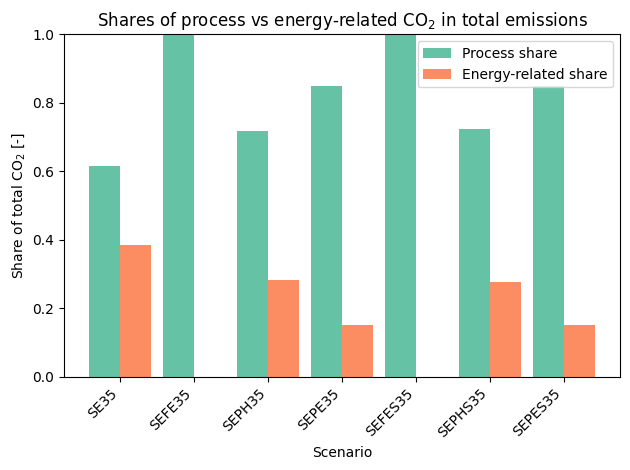

In [28]:
# --- Cell C3: CO2 shares (process vs energy-related) by scenario ---

import matplotlib.pyplot as plt
import numpy as np

x = co2_scen["scenario_name"].astype(str).tolist()
idx = np.arange(len(x))
w = 0.42

proc_share = co2_scen["process_share"].values
en_share = co2_scen["energy_share"].values

cmap = plt.get_cmap("Set2")
col_process = cmap(0)
col_energy = cmap(1)

plt.figure()
plt.bar(idx - w/2, proc_share, width=w, label="Process share", color=col_process)
plt.bar(idx + w/2, en_share, width=w, label="Energy-related share", color=col_energy)

plt.ylabel("Share of total CO$_2$ [-]")
plt.xlabel("Scenario")
plt.title("Shares of process vs energy-related CO$_2$ in total emissions")
plt.xticks(idx, x, rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
# --- Cell E1: Derive cost components and reconcile with Total Variable Cost ---

import numpy as np
import pandas as pd

need = [
    "Elec Price [€/MWh_e]",
    "NG Price [€/MWh_th]",
    "Coal Price [€/MWh_th]",
    "H2 Price [€/MWh_th]",
    "CO2 Price [€/tCO2]",
    "Total Variable Cost [€]",
    "Total CO2 [tCO2/step]",
    "dt_hours",
    "Clinker Rate [t/h]",
    "Total Power Input [MW_e]",
    "Calciner NG [MW_th]", "Calciner Coal [MW_th]", "Calciner H2 [MW_th]",
    "Kiln NG [MW_th]", "Kiln Coal [MW_th]", "Kiln H2 [MW_th]",
]
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns for economic analysis: {missing}")

tmp = df.copy()
tmp["dt_hours"] = tmp["dt_hours"].fillna(1.0)

# Energy quantities per step
tmp["elec_MWh"] = tmp["Total Power Input [MW_e]"] * tmp["dt_hours"]

tmp["ng_MWhth"] = (tmp["Calciner NG [MW_th]"] + tmp["Kiln NG [MW_th]"]) * tmp["dt_hours"]
tmp["coal_MWhth"] = (tmp["Calciner Coal [MW_th]"] + tmp["Kiln Coal [MW_th]"]) * tmp["dt_hours"]
tmp["h2_MWhth"] = (tmp["Calciner H2 [MW_th]"] + tmp["Kiln H2 [MW_th]"]) * tmp["dt_hours"]

tmp["clinker_t"] = tmp["Clinker Rate [t/h]"] * tmp["dt_hours"]

# Cost components per step
tmp["cost_elec_eur"] = tmp["elec_MWh"] * tmp["Elec Price [€/MWh_e]"]
tmp["cost_ng_eur"] = tmp["ng_MWhth"] * tmp["NG Price [€/MWh_th]"]
tmp["cost_coal_eur"] = tmp["coal_MWhth"] * tmp["Coal Price [€/MWh_th]"]
tmp["cost_h2_eur"] = tmp["h2_MWhth"] * tmp["H2 Price [€/MWh_th]"]

# CO2 is tCO2/step already -> cost per step
tmp["cost_co2_eur"] = tmp["Total CO2 [tCO2/step]"] * tmp["CO2 Price [€/tCO2]"]

tmp["cost_sum_eur"] = (
    tmp["cost_elec_eur"] + tmp["cost_ng_eur"] + tmp["cost_coal_eur"] + tmp["cost_h2_eur"] + tmp["cost_co2_eur"]
)

# Scenario-level aggregation (portfolio, sum across plants)
econ_scen = (
    tmp.groupby("scenario_name", as_index=False)
    .agg(
        clinker_t=("clinker_t", "sum"),
        var_cost_eur_reported=("Total Variable Cost [€]", "sum"),
        cost_sum_eur_derived=("cost_sum_eur", "sum"),
        cost_elec_eur=("cost_elec_eur", "sum"),
        cost_ng_eur=("cost_ng_eur", "sum"),
        cost_coal_eur=("cost_coal_eur", "sum"),
        cost_h2_eur=("cost_h2_eur", "sum"),
        cost_co2_eur=("cost_co2_eur", "sum"),
        elec_MWh=("elec_MWh", "sum"),
        ng_MWhth=("ng_MWhth", "sum"),
        coal_MWhth=("coal_MWhth", "sum"),
        h2_MWhth=("h2_MWhth", "sum"),
        co2_t=("Total CO2 [tCO2/step]", "sum"),
    )
)

# Reconciliation metrics
econ_scen["recon_gap_eur"] = econ_scen["var_cost_eur_reported"] - econ_scen["cost_sum_eur_derived"]
econ_scen["recon_gap_pct"] = econ_scen["recon_gap_eur"] / econ_scen["var_cost_eur_reported"].replace(0, np.nan)

# Intensities
econ_scen["eur_per_t_clinker"] = econ_scen["var_cost_eur_reported"] / econ_scen["clinker_t"].replace(0, np.nan)
econ_scen["eur_per_t_clinker_derived"] = econ_scen["cost_sum_eur_derived"] / econ_scen["clinker_t"].replace(0, np.nan)

# Order rows
scenario_order = ["SE35", "SEFE35", "SEPH35", "SEPE35", "SEFES35", "SEPHS35", "SEPES35"]
econ_scen["scenario_name"] = pd.Categorical(econ_scen["scenario_name"], categories=scenario_order, ordered=True)
econ_scen = econ_scen.sort_values("scenario_name").reset_index(drop=True)

display(econ_scen[[
    "scenario_name",
    "var_cost_eur_reported","cost_sum_eur_derived","recon_gap_eur","recon_gap_pct",
    "eur_per_t_clinker","eur_per_t_clinker_derived"
]])


,scenario_name,var_cost_eur_reported,cost_sum_eur_derived,recon_gap_eur,recon_gap_pct,eur_per_t_clinker,eur_per_t_clinker_derived
0,SE35,1.770040e+09,1.770027e+09,1.273212e+04,7.193127e-06,147.816160,147.815097
1,SEFE35,1.979087e+09,1.979087e+09,2.384186e-07,1.204690e-16,165.273728,165.273728
2,SEPH35,2.101371e+09,1.992765e+09,1.086060e+08,5.168339e-02,175.485669,166.415974
3,SEPE35,1.991659e+09,1.946389e+09,4.527014e+07,2.272986e-02,166.323609,162.543097
4,SEFES35,1.902428e+09,0.000000e+00,1.902428e+09,1.000000e+00,158.871880,0.000000
5,SEPHS35,2.094350e+09,0.000000e+00,2.094350e+09,1.000000e+00,174.899363,0.000000
6,SEPES35,1.900469e+09,0.000000e+00,1.900469e+09,1.000000e+00,158.708311,0.000000


In [30]:
# --- Cell E2: Scenario-level economic KPI table (scenario_name only) ---

scenario_kpis = econ_scen[[
    "scenario_name",
    "clinker_t",
    "co2_t",
    "elec_MWh","ng_MWhth","coal_MWhth","h2_MWhth",
    "var_cost_eur_reported",
    "eur_per_t_clinker",
    "cost_elec_eur","cost_ng_eur","cost_coal_eur","cost_h2_eur","cost_co2_eur",
    "recon_gap_pct",
]].copy()

display(scenario_kpis)


,scenario_name,clinker_t,co2_t,elec_MWh,ng_MWhth,coal_MWhth,h2_MWhth,var_cost_eur_reported,eur_per_t_clinker,cost_elec_eur,cost_ng_eur,cost_coal_eur,cost_h2_eur,cost_co2_eur,recon_gap_pct
0,SE35,11974602.48,1.045137e+07,0.000000e+00,0.000000e+00,1.182692e+07,0.000000e+00,1.770040e+09,147.816160,0.000000e+00,0.000000e+00,9.780859e+07,0.0,1.672218e+09,7.193127e-06
1,SEFE35,11974602.48,6.418387e+06,1.385421e+07,0.000000e+00,0.000000e+00,0.000000e+00,1.979087e+09,165.273728,9.521453e+08,0.000000e+00,0.000000e+00,0.0,1.026942e+09,1.204690e-16
2,SEPH35,11974602.48,8.940837e+06,3.993451e+06,8.781375e+06,2.195344e+06,3.326545e+06,2.101371e+09,175.485669,2.722922e+08,2.717836e+08,1.815549e+07,0.0,1.430534e+09,5.168339e-02
3,SEPE35,11974602.48,7.528789e+06,1.039900e+07,0.000000e+00,3.326545e+06,0.000000e+00,1.991659e+09,166.323609,7.142721e+08,0.000000e+00,2.751052e+07,0.0,1.204606e+09,2.272986e-02
4,SEFES35,11974602.48,6.418387e+06,1.396204e+07,0.000000e+00,0.000000e+00,0.000000e+00,1.902428e+09,158.871880,8.754857e+08,0.000000e+00,0.000000e+00,0.0,1.026942e+09,1.000000e+00
5,SEPHS35,11974602.48,8.867924e+06,4.300477e+06,8.527544e+06,2.131886e+06,3.326545e+06,2.094350e+09,174.899363,2.853183e+08,2.639275e+08,1.763070e+07,0.0,1.418868e+09,1.000000e+00
6,SEPES35,11974602.48,7.528789e+06,1.048485e+07,0.000000e+00,3.326545e+06,0.000000e+00,1.900469e+09,158.708311,6.230820e+08,0.000000e+00,2.751052e+07,0.0,1.204606e+09,1.000000e+00


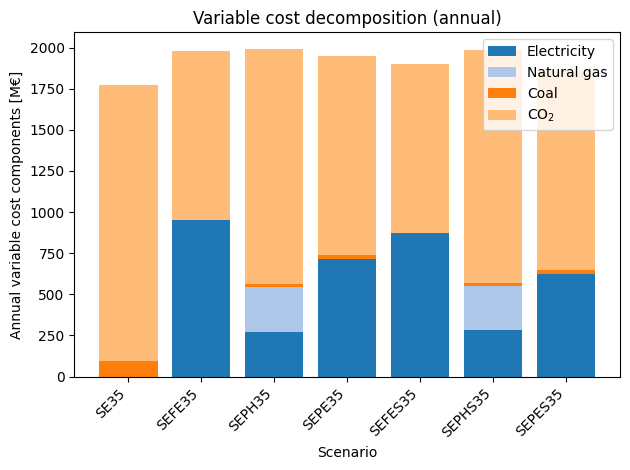

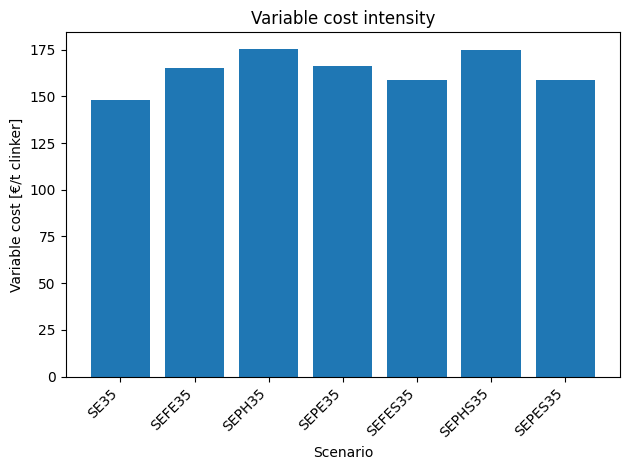

In [31]:
# --- Cell E3a: Stacked cost composition by scenario (M€) ---

import matplotlib.pyplot as plt
import numpy as np

plot_df = scenario_kpis.copy()
plot_df = plot_df.sort_values("scenario_name")

x = plot_df["scenario_name"].astype(str).tolist()
bottom = np.zeros(len(plot_df))

# Convert to M€ for readability
components = [
    ("cost_elec_eur", "Electricity"),
    ("cost_ng_eur", "Natural gas"),
    ("cost_coal_eur", "Coal"),
    # ("cost_h2_eur", "Hydrogen"),
    ("cost_co2_eur", "CO$_2$"),
]

cmap = plt.get_cmap("tab20")
plt.figure()

for i, (col, label) in enumerate(components):
    y = (plot_df[col].values / 1e6)
    plt.bar(x, y, bottom=bottom, label=label, color=cmap(i))
    bottom += y

plt.ylabel("Annual variable cost components [M€]")
plt.xlabel("Scenario")
plt.title("Variable cost decomposition (annual)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


# --- Cell E3b: Total cost intensity by scenario (€/t clinker) ---

plt.figure()
plt.bar(plot_df["scenario_name"].astype(str), plot_df["eur_per_t_clinker"].values)
plt.ylabel("Variable cost [€/t clinker]")
plt.xlabel("Scenario")
plt.title("Variable cost intensity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [32]:
# --- Cell K1: Scenario-level economic + load KPIs (scenario_name only) ---

import numpy as np
import pandas as pd

# Required columns
req = [
    "scenario_name", "dt_hours",
    "Clinker Rate [t/h]",
    "Total Variable Cost [€]",
    "Total Power Input [MW_e]",
    "Elec Price [€/MWh_e]",
    "Total CO2 [tCO2/step]",
    "CO2 Price [€/tCO2]",
    "Calciner NG [MW_th]", "Kiln NG [MW_th]",
    "Calciner Coal [MW_th]", "Kiln Coal [MW_th]",
    "Calciner H2 [MW_th]", "Kiln H2 [MW_th]",
    "NG Price [€/MWh_th]", "Coal Price [€/MWh_th]", "H2 Price [€/MWh_th]",
]
missing = [c for c in req if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns for KPI table: {missing}")

tmp = df.copy()
tmp["dt_hours"] = tmp["dt_hours"].fillna(1.0)

# Annual physical totals
tmp["clinker_t"] = tmp["Clinker Rate [t/h]"] * tmp["dt_hours"]
tmp["elec_MWh"] = tmp["Total Power Input [MW_e]"] * tmp["dt_hours"]

# Fuel thermal energy (MWh_th)
tmp["ng_MWhth"]   = (tmp["Calciner NG [MW_th]"]   + tmp["Kiln NG [MW_th]"])   * tmp["dt_hours"]
tmp["coal_MWhth"] = (tmp["Calciner Coal [MW_th]"] + tmp["Kiln Coal [MW_th]"]) * tmp["dt_hours"]
tmp["h2_MWhth"]   = (tmp["Calciner H2 [MW_th]"]   + tmp["Kiln H2 [MW_th]"])   * tmp["dt_hours"]

# Cost components (annual sums are sums over hours)
tmp["cost_elec_eur"] = tmp["elec_MWh"] * tmp["Elec Price [€/MWh_e]"]
tmp["cost_ng_eur"]   = tmp["ng_MWhth"]   * tmp["NG Price [€/MWh_th]"]
tmp["cost_coal_eur"] = tmp["coal_MWhth"] * tmp["Coal Price [€/MWh_th]"]
tmp["cost_h2_eur"]   = tmp["h2_MWhth"]   * tmp["H2 Price [€/MWh_th]"]
tmp["cost_co2_eur"]  = tmp["Total CO2 [tCO2/step]"] * tmp["CO2 Price [€/tCO2]"]

# Scenario aggregation
kpi = (
    tmp.groupby("scenario_name", as_index=False)
    .agg(
        clinker_t=("clinker_t", "sum"),
        var_cost_eur=("Total Variable Cost [€]", "sum"),

        elec_MWh=("elec_MWh", "sum"),
        cost_elec_eur=("cost_elec_eur", "sum"),

        cost_co2_eur=("cost_co2_eur", "sum"),

        # demand shape
        peak_total_power_MW=("Total Power Input [MW_e]", "max"),
        p95_total_power_MW=("Total Power Input [MW_e]", lambda s: float(np.quantile(s, 0.95))),
        avg_total_power_MW=("Total Power Input [MW_e]", "mean"),
    )
)

# KPIs requested
kpi["total_variable_cost_intensity_eur_per_t"] = kpi["var_cost_eur"] / kpi["clinker_t"].replace(0, np.nan)
kpi["electricity_intensity_MWh_per_t"] = kpi["elec_MWh"] / kpi["clinker_t"].replace(0, np.nan)

# Consumption-weighted average electricity price paid
kpi["elec_price_weighted_eur_per_MWh"] = kpi["cost_elec_eur"] / kpi["elec_MWh"].replace(0, np.nan)

# Share of variable cost from electricity (%)
kpi["share_elec_cost_pct"] = 100.0 * kpi["cost_elec_eur"] / kpi["var_cost_eur"].replace(0, np.nan)

# CO2 cost intensity and share (%)
kpi["co2_cost_intensity_eur_per_t"] = kpi["cost_co2_eur"] / kpi["clinker_t"].replace(0, np.nan)
kpi["share_co2_cost_pct"] = 100.0 * kpi["cost_co2_eur"] / kpi["var_cost_eur"].replace(0, np.nan)

# Load factor (avg/peak)
kpi["load_factor_avg_over_peak"] = kpi["avg_total_power_MW"] / kpi["peak_total_power_MW"].replace(0, np.nan)

# Order rows by scenario_name (recommended)
scenario_order = ["SE35", "SEFE35", "SEPH35", "SEPE35", "SEFES35", "SEPHS35", "SEPES35"]
kpi["scenario_name"] = pd.Categorical(kpi["scenario_name"], categories=scenario_order, ordered=True)
kpi = kpi.sort_values("scenario_name").reset_index(drop=True)

# Display only the requested KPIs (clean table)
kpi_table = kpi[[
    "scenario_name",
    "total_variable_cost_intensity_eur_per_t",
    "electricity_intensity_MWh_per_t",
    "elec_price_weighted_eur_per_MWh",
    "share_elec_cost_pct",
    "co2_cost_intensity_eur_per_t",
    "share_co2_cost_pct",
    "peak_total_power_MW",
    "p95_total_power_MW",
    "load_factor_avg_over_peak",
]].copy()

display(kpi_table)


,scenario_name,total_variable_cost_intensity_eur_per_t,electricity_intensity_MWh_per_t,elec_price_weighted_eur_per_MWh,share_elec_cost_pct,co2_cost_intensity_eur_per_t,share_co2_cost_pct,peak_total_power_MW,p95_total_power_MW,load_factor_avg_over_peak
0,SE35,147.816160,0.000000,NaN,0.000000,139.647093,94.473496,0.000000,0.000000,NaN
1,SEFE35,165.273728,1.156966,68.726075,48.110325,85.760000,51.889675,320.861365,305.948074,0.616127
2,SEPH35,175.485669,0.333493,68.184681,12.957834,119.464000,68.076214,92.487724,88.188994,0.616127
3,SEPE35,166.323609,0.868421,68.686638,35.863172,100.596768,60.482555,240.839211,229.645263,0.616127
4,SEFES35,158.871880,1.165971,62.704714,46.019396,85.760000,53.980604,336.000000,324.553506,0.592946
5,SEPHS35,174.899363,0.359133,66.345734,13.623237,118.489766,67.747397,97.110000,97.110000,0.631915
6,SEPES35,158.708311,0.875591,59.426885,32.785696,100.596768,63.384688,252.880000,252.880000,0.591635


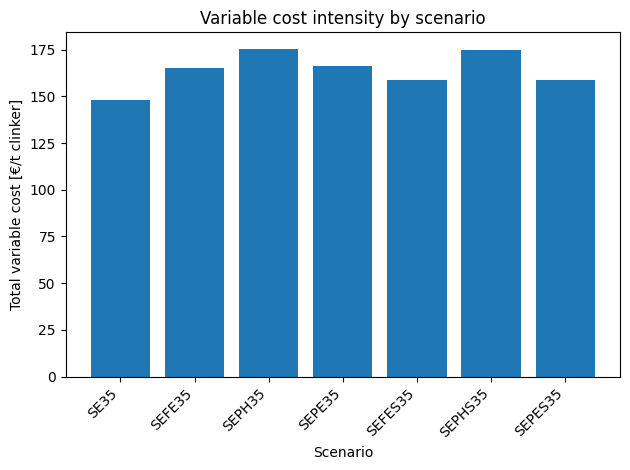

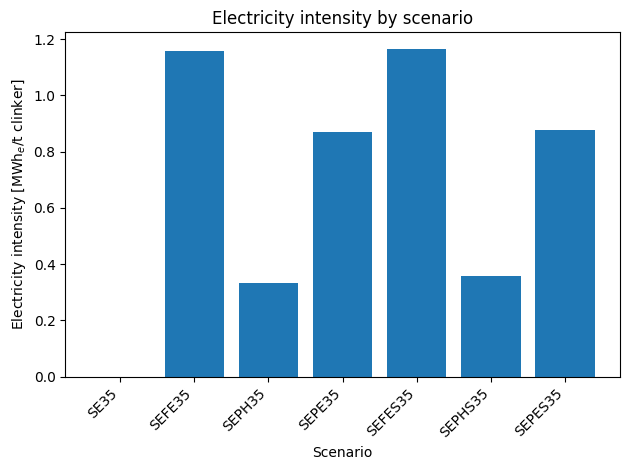

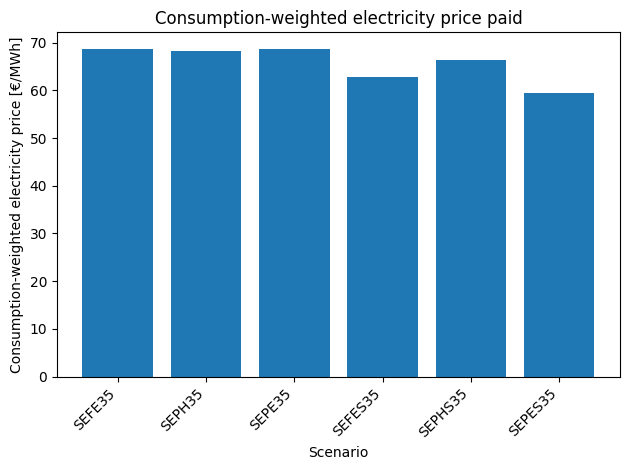

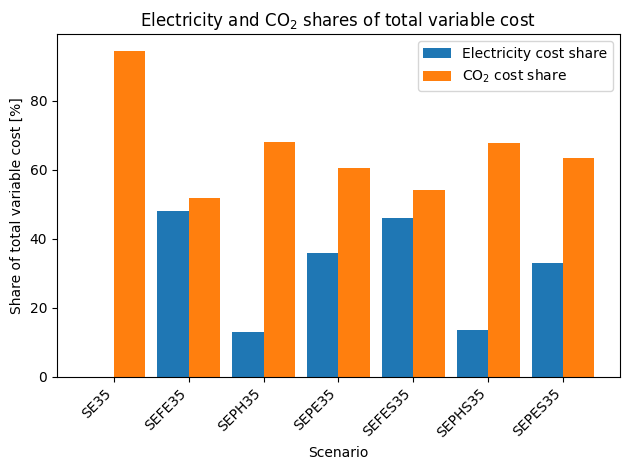

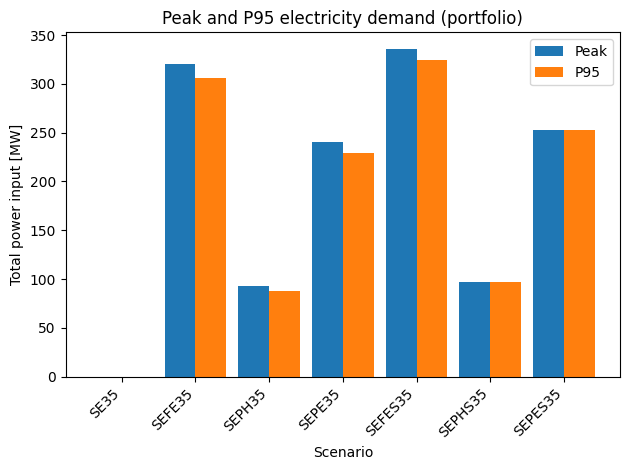

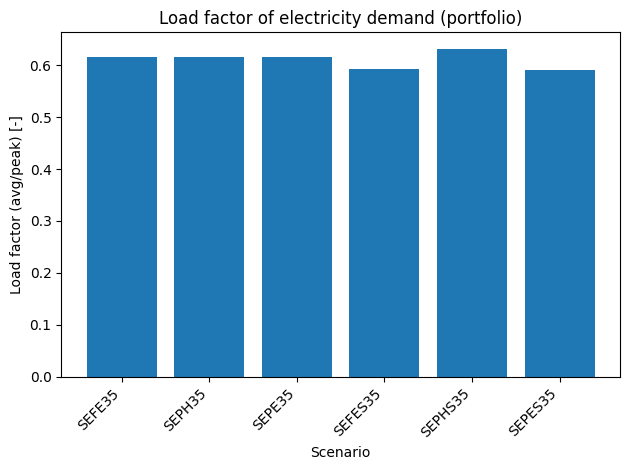

In [33]:
# --- Cell K2: KPI plots (scenario_name only) ---

import matplotlib.pyplot as plt
import numpy as np

if "kpi_table" not in globals():
    raise NameError("Run Cell K1 first to create 'kpi_table'.")

x = kpi_table["scenario_name"].astype(str).tolist()

# (1) Cost intensity (€/t clinker)
plt.figure()
plt.bar(x, kpi_table["total_variable_cost_intensity_eur_per_t"].values)
plt.ylabel("Total variable cost [€/t clinker]")
plt.xlabel("Scenario")
plt.title("Variable cost intensity by scenario")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# (2) Electricity intensity (MWh/t clinker)
plt.figure()
plt.bar(x, kpi_table["electricity_intensity_MWh_per_t"].values)
plt.ylabel("Electricity intensity [MWh$_e$/t clinker]")
plt.xlabel("Scenario")
plt.title("Electricity intensity by scenario")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# (3) Consumption-weighted electricity price paid (€/MWh)
plt.figure()
plt.bar(x, kpi_table["elec_price_weighted_eur_per_MWh"].values)
plt.ylabel("Consumption-weighted electricity price [€/MWh]")
plt.xlabel("Scenario")
plt.title("Consumption-weighted electricity price paid")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# (4) Shares of variable cost: electricity vs CO2 (side-by-side bars)
idx = np.arange(len(x))
w = 0.42

plt.figure()
plt.bar(idx - w/2, kpi_table["share_elec_cost_pct"].values, width=w, label="Electricity cost share")
plt.bar(idx + w/2, kpi_table["share_co2_cost_pct"].values, width=w, label="CO$_2$ cost share")
plt.ylabel("Share of total variable cost [%]")
plt.xlabel("Scenario")
plt.title("Electricity and CO$_2$ shares of total variable cost")
plt.xticks(idx, x, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# (5) Peak and p95 demand (MW) (side-by-side)
plt.figure()
plt.bar(idx - w/2, kpi_table["peak_total_power_MW"].values, width=w, label="Peak")
plt.bar(idx + w/2, kpi_table["p95_total_power_MW"].values, width=w, label="P95")
plt.ylabel("Total power input [MW]")
plt.xlabel("Scenario")
plt.title("Peak and P95 electricity demand (portfolio)")
plt.xticks(idx, x, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# (6) Load factor (avg/peak)
plt.figure()
plt.bar(x, kpi_table["load_factor_avg_over_peak"].values)
plt.ylabel("Load factor (avg/peak) [-]")
plt.xlabel("Scenario")
plt.title("Load factor of electricity demand (portfolio)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


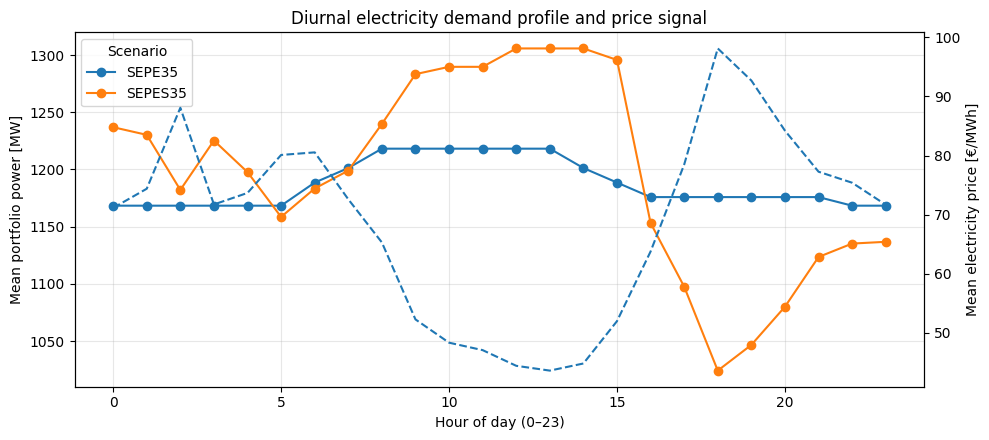

In [37]:
# --- Cell D1: Diurnal (hour-of-day) mean load profile + mean price overlay ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Choose scenarios to compare (example: PE without TES vs PE with TES)
scenario_noTES = "SEPE35"
scenario_TES   = "SEPES35"

need = ["scenario_name", "timestamp", "Total Power Input [MW_e]", "Elec Price [€/MWh_e]"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns for diurnal profile plot: {missing}")

tmp = df[df["scenario_name"].isin([scenario_noTES, scenario_TES])].copy()
tmp["hour"] = pd.to_datetime(tmp["timestamp"]).dt.hour

# Portfolio aggregation first: sum across plants within each hour timestamp
portfolio = (
    tmp.groupby(["scenario_name", "timestamp", "hour"], as_index=False)
    .agg(
        total_power_MW=("Total Power Input [MW_e]", "sum"),
        price_eur_per_mwh=("Elec Price [€/MWh_e]", "mean"),  # same price across plants; mean is safe
    )
)

# Then diurnal averages by hour-of-day
diurnal = (
    portfolio.groupby(["scenario_name", "hour"], as_index=False)
    .agg(
        mean_total_power_MW=("total_power_MW", "mean"),
        mean_price=("price_eur_per_mwh", "mean"),
    )
)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 4.5))

for sc in [scenario_noTES, scenario_TES]:
    d = diurnal[diurnal["scenario_name"] == sc].sort_values("hour")
    ax1.plot(d["hour"], d["mean_total_power_MW"], marker="o", label=sc)

ax1.set_xlabel("Hour of day (0–23)")
ax1.set_ylabel("Mean portfolio power [MW]")
ax1.set_title("Diurnal electricity demand profile and price signal")
ax1.grid(True, which="both", alpha=0.3)

# Price on secondary axis (single series; average across both scenarios)
ax2 = ax1.twinx()
price_by_hour = diurnal.groupby("hour", as_index=False)["mean_price"].mean().sort_values("hour")
ax2.plot(price_by_hour["hour"], price_by_hour["mean_price"], linestyle="--")
ax2.set_ylabel("Mean electricity price [€/MWh]")

ax1.legend(title="Scenario", loc="upper left")
plt.tight_layout()
plt.show()


Corr(delta load, price) = -0.240 (negative suggests shifting away from high prices)


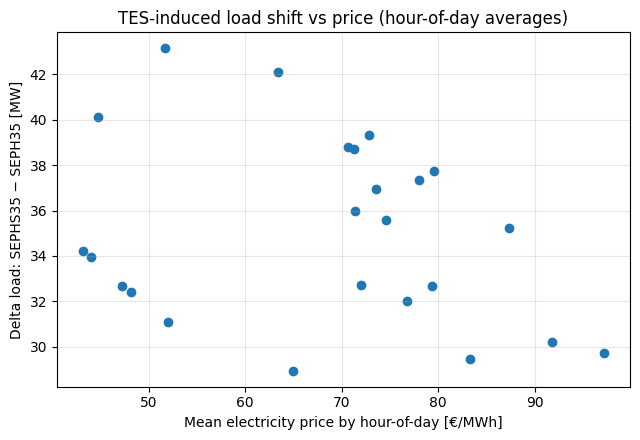

,hour,price,delta_MW_TES_minus_noTES
0,0,70.702364,38.815897
1,1,73.552025,36.934517
2,2,87.353469,35.249476
3,3,71.321466,38.708035
4,4,72.858042,39.344277
5,5,79.551375,37.728661
6,6,79.382030,32.673420
7,7,72.050678,32.742895
8,8,64.976027,28.950054
9,9,52.035323,31.087378


In [35]:
# --- Cell D2: TES-induced delta load vs mean price (hour-of-day) + correlation ---

# Pivot diurnal to compute TES - noTES difference
pivot = diurnal.pivot(index="hour", columns="scenario_name", values="mean_total_power_MW").reset_index()

if scenario_noTES not in pivot.columns or scenario_TES not in pivot.columns:
    raise KeyError("Chosen scenarios not found in diurnal pivot. Check scenario names.")

pivot["delta_MW_TES_minus_noTES"] = pivot[scenario_TES] - pivot[scenario_noTES]

# Add price
pivot = pivot.merge(price_by_hour.rename(columns={"mean_price": "price"}), on="hour", how="left")

# Correlation (simple diagnostic)
corr = np.corrcoef(pivot["delta_MW_TES_minus_noTES"], pivot["price"])[0, 1]
print(f"Corr(delta load, price) = {corr:.3f} (negative suggests shifting away from high prices)")

# Scatter
plt.figure(figsize=(6.5, 4.5))
plt.scatter(pivot["price"], pivot["delta_MW_TES_minus_noTES"])
plt.xlabel("Mean electricity price by hour-of-day [€/MWh]")
plt.ylabel(f"Delta load: {scenario_TES} − {scenario_noTES} [MW]")
plt.title("TES-induced load shift vs price (hour-of-day averages)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(pivot[["hour","price","delta_MW_TES_minus_noTES"]].sort_values("hour"))


,scenario_name,price_thr_p90,mwh_share_above_p90,price_thr_p95,mwh_share_above_p95
0,SEPH35,175.43,0.099642,195.49,0.053567
1,SEPHS35,175.43,0.092535,195.49,0.049746


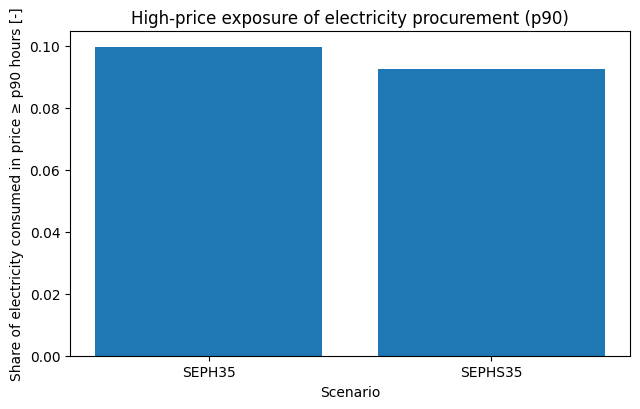

In [36]:
# --- Cell D3: High-price exposure metrics (share of MWh consumed above p90/p95 price) ---

def high_price_exposure(df_in, scenario, q=0.90):
    s = df_in[df_in["scenario_name"] == scenario].copy()
    s["dt_hours"] = s["dt_hours"].fillna(1.0)
    s["elec_MWh"] = s["Total Power Input [MW_e]"] * s["dt_hours"]

    # Portfolio price series (mean across plants per timestamp)
    pr = s.groupby("timestamp", as_index=False)["Elec Price [€/MWh_e]"].mean()
    thr = float(pr["Elec Price [€/MWh_e]"].quantile(q))

    # Portfolio electricity per timestamp
    e = s.groupby("timestamp", as_index=False)["elec_MWh"].sum()
    m = e.merge(pr, on="timestamp", how="left")

    share = m.loc[m["Elec Price [€/MWh_e]"] >= thr, "elec_MWh"].sum() / m["elec_MWh"].sum()
    return thr, float(share)

rows = []
for sc in [scenario_noTES, scenario_TES]:
    thr90, sh90 = high_price_exposure(df, sc, 0.90)
    thr95, sh95 = high_price_exposure(df, sc, 0.95)
    rows.append({"scenario_name": sc, "price_thr_p90": thr90, "mwh_share_above_p90": sh90,
                 "price_thr_p95": thr95, "mwh_share_above_p95": sh95})

exposure = pd.DataFrame(rows)
display(exposure)

# Simple bar plot for p90 share
plt.figure(figsize=(6.5, 4.2))
plt.bar(exposure["scenario_name"], exposure["mwh_share_above_p90"])
plt.ylabel("Share of electricity consumed in price ≥ p90 hours [-]")
plt.xlabel("Scenario")
plt.title("High-price exposure of electricity procurement (p90)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
